# Choix du modèle — Benchmark médical pour le triage d'urgence

Notebook **indépendant** : ré-entraîne tous les modèles sur les 4 scénarios
pour justifier le choix final du modèle déployé en production.

---

## Contexte médical

**Objectif :** prédire le niveau d'urgence d'un patient (`0` non urgent / `1` urgent / `2` vital)
à partir de données hybrides en télémédecine (constantes vitales + texte libre).

**Toutes les erreurs ne se valent pas :**

| Erreur | Conséquence | Gravité |
|--------|-------------|---------|
| Classe 2 prédit en 0 | Patient vital traité comme non urgent → risque vital | Inacceptable |
| Classe 2 prédit en 1 | Patient vital traité comme urgent → retard de soins | Grave |
| Classe 1 prédit en 0 | Urgence relative non prioritarisée | Sérieux |
| Classe 0 prédit en 1 | Fausse alarme → surcharge évitable | Acceptable |

**→ Minimiser le sous-triage vital (classe 2 manquée) est la contrainte numéro 1.**

## Métriques retenues

| Métrique | Justification |
|----------|---------------|
| **Recall classe 2** | Éviter le sous-triage mortel — priorité absolue |
| **Recall classe 1** | Ne pas rater les urgences relatives |
| **Précision classe 0** | Quand on dit "pas urgent", est-on vraiment sûr ? Éviter de renvoyer chez eux des patients qui ne l'étaient pas |
| **Matrice de confusion** | Vue complète des erreurs par classe |
| **Ressources** | Latence d'inférence, RAM, temps d'entraînement |

> **Pourquoi pas l'accuracy ou le F1 pondéré ?**
> Ces métriques globales sont dominées par les classes majoritaires.
> Un modèle qui ignore presque tous les cas vitaux peut quand même afficher une bonne accuracy.
> Ce sont de mauvaises boussoles pour un problème à coût asymétrique.

## Stratégie de pénalisation

Deux mécanismes complémentaires forcent les modèles à prioriser la classe 2 :

1. **`class_weight = {0: 1, 1: 6, 2: 15}`** — une erreur classe 2 pèse 15x plus.
   Mêmes poids sur les 4 scénarios pour garantir une comparaison équitable.

2. **Seuils abaissés `{2: 0.15, 1: 0.20}`** — classé vital dès que P(vital) >= 0.15
   (contre ~0.33 par défaut avec argmax). Favorise la détection au prix d'un léger sur-triage.

Chaque scénario est évalué **avec et sans** ces mécanismes pour quantifier leur apport.

---
## Modèles retenus

### Pourquoi la classification supervisée ?

Le problème consiste à **prédire une catégorie parmi trois** (`0` non urgent / `1` urgent / `2` vital). C'est donc de la **classification** — on cherche à assigner chaque patient à une classe discrète, pas à estimer une valeur continue (ce serait de la régression).

C'est de la classification **supervisée** parce qu'on dispose de labels connus dans le dataset : chaque patient a un niveau d'urgence renseigné. Le modèle apprend pendant l'entraînement à associer des features à ces labels, puis généralise sur de nouveaux patients non vus.

Ces deux contraintes — prédire une classe parmi 3, avec des exemples étiquetés — orientent naturellement vers les algorithmes classiques de classification supervisée ci-dessous. Les approches non supervisées (clustering) ou la régression ne sont pas adaptées ici.

| Modèle | Famille | Raison du choix |
|--------|---------|-----------------|
| **LogisticRegression** | Linéaire | Baseline interprétable, rapide, référence de comparaison |
| **RandomForest** | Ensemble (bagging) | Robuste, supporte `class_weight`, peu sensible aux hyperparamètres |
| **XGBoost** | Ensemble (boosting) | Très performant sur tabulaire, pénalisation via `sample_weight` |
| **LightGBM** | Ensemble (boosting) | Plus rapide que XGBoost, supporte `class_weight` directement |
| **NeuralNetwork** | Réseau dense MLP | Capture des non-linéarités complexes, supporte `class_weight` via Keras |

### Pourquoi KNN est exclu

`KNeighborsClassifier` (scikit-learn) ne supporte **pas** le paramètre `class_weight` :
il ne peut pas pénaliser différemment les erreurs selon la classe.

**→ KNN est exclu** pour garantir que tous les modèles jouent dans les mêmes conditions.

In [1]:
# Imports
import os, io, time, warnings, tracemalloc
import numpy as np
import scipy.sparse as sp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import (
    precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

try:
    import psutil
    _PSUTIL = True
except ImportError:
    _PSUTIL = False

warnings.filterwarnings("ignore")


# Le notebook est dans backend/scenarios/ — je remonte deux niveaux pour accéder au dataset
_DATA_PATH = os.path.normpath(
    os.path.join(os.getcwd(), "..", "..", "dataset_telemed.csv")
)


# ─── Colonnes du dataset ───────────────────────────────────────────────────

# L'ID patient n'a aucune valeur prédictive — je le supprime avant l'entraînement
_TRASH   = ["patient_id"]

# Les mesures physiologiques du patient
_NUM_COL = ["age", "freq_cardiaque", "frequence_cardiaque", "tension_sys",
            "temp", "sat_oxygene", "antecedents", "duree_symptomes"]

# Informations démographiques et canal de contact
_CAT_COL = ["sexe", "zone_vie", "source"]

# La description libre des symptômes, que je vectorise avec TF-IDF
_TXT_COL = ["description_symptomes"]

# Tranches d'âge médicalement significatives, utilisées dans le scénario éthique
_AGE_BINS   = [0, 17, 40, 64, float("inf")]
_AGE_LABELS = ["enfant", "adulte_jeune", "adulte", "senior"]

# Valeurs physiquement impossibles — pas des seuils cliniques, juste des limites absolues
# Une SpO2 à 78% ou une FC à 180 bpm sont possibles et doivent être conservées
_BORNES_IMPOSSIBLES = {
    "age":             (0, 130),
    "freq_cardiaque":  (0, 400),
    "tension_sys":     (0, 400),
    "temp":            (0, 60),
    "sat_oxygene":     (0, 100),
    "duree_symptomes": (0, None),
    "antecedents":     (0, 1),
}


# ─── Règles métiers ────────────────────────────────────────────────────────

def apply_business_rules(df):
    df = df.copy()
    rapport = []
    # Je supprime les lignes entièrement dupliquées — elles faussent l'entraînement
    n_avant = len(df)
    df = df.drop_duplicates()
    n_supprime = n_avant - len(df)
    if n_supprime > 0:
        rapport.append(f"Doublons complets supprimés : {n_supprime} ligne(s) ({n_avant} → {len(df)})")
    for col, (min_val, max_val) in _BORNES_IMPOSSIBLES.items():
        if col not in df.columns:
            continue
        masque = pd.Series(False, index=df.index)
        if min_val is not None:
            masque |= df[col] < min_val
        if max_val is not None:
            masque |= df[col] > max_val
        n = masque.sum()
        if n > 0:
            df[col] = df[col].clip(lower=min_val, upper=max_val)
            rapport.append(f"{col} : {n} valeur(s) impossible(s) → clippées")
    print("=" * 55 + "\n     RAPPORT RÈGLES MÉTIERS\n" + "=" * 55)
    if rapport:
        for l in rapport:
            print(f"  • {l}")
    else:
        print("  Aucune valeur impossible détectée.")
    print("=" * 55)
    return df


# ─── Preprocessing éthique ─────────────────────────────────────────────────
# Je supprime sexe et zone_vie (RGPD + biais potentiel) et je remplace l'âge
# précis par une tranche médicale pour réduire le risque de ré-identification.

def ethical_preprocessing(df, sensitive_cols=None):
    df = df.copy()
    rapport = []
    if "age" in df.columns:
        df["age"] = pd.cut(df["age"], bins=_AGE_BINS, labels=_AGE_LABELS, right=True)
        rapport.append("age : généralisation → tranches [enfant | adulte_jeune | adulte | senior]")
    if sensitive_cols is not None:
        present = [c for c in sensitive_cols if c in df.columns]
        df = df.drop(columns=present)
        rapport.append(f"Variables sensibles supprimées : {present}")
    print("=" * 55 + "\n    RAPPORT PREPROCESSING ÉTHIQUE\n" + "=" * 55)
    for l in rapport:
        print(f"  • {l}")
    print("=" * 55)
    return df


# ─── Preprocessing tabulaire ───────────────────────────────────────────────
# Pipeline standard : imputation → normalisation/encodage → DataFrame.
# Je fitte uniquement sur le train pour éviter toute fuite d'information du test.

def preprocessingTechnique(df, target_col, to_drop=None, num_cols=None, cat_cols=None):
    df = df.copy()
    rapport = []
    if to_drop:
        dropped = [c for c in to_drop if c in df.columns]
        df = df.drop(columns=to_drop, errors="ignore")
        rapport.append(f"Colonnes supprimées ({len(dropped)}) : {dropped}")
    X = df.drop(columns=[target_col])
    y = df[target_col]
    if num_cols is None:
        num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    if cat_cols is None:
        cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    rapport.append(f"Colonnes numériques fournies ({len(num_cols)}) : {num_cols}")
    rapport.append(f"Colonnes catégorielles fournies ({len(cat_cols)}) : {cat_cols}")
    # Médiane robuste aux outliers médicaux, MinMax pour homogénéiser les échelles entre variables
    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  MinMaxScaler()),
    ])
    # Mode pour les NA, OneHot pour ne pas créer d'ordre implicite entre les modalités
    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    transformers = []
    if num_cols:
        transformers.append(("num", num_pipeline, num_cols))
        rapport.append("Numériques → imputation médiane + MinMaxScaler")
    if cat_cols:
        transformers.append(("cat", cat_pipeline, cat_cols))
        rapport.append("Catégorielles → imputation mode + OneHotEncoder")
    preprocessor = ColumnTransformer(transformers)
    X_processed  = preprocessor.fit_transform(X)
    feature_names = preprocessor.get_feature_names_out()
    X_processed  = pd.DataFrame(X_processed, columns=feature_names)
    df_final     = pd.concat([X_processed, y.reset_index(drop=True)], axis=1)
    nan_avant = df.drop(columns=[target_col]).isnull().sum().sum()
    nan_apres = X_processed.isnull().sum().sum()
    rapport.append(f"Valeurs manquantes avant : {nan_avant} → après : {nan_apres}")
    rapport.append(f"Dimensions avant  : {df.drop(columns=[target_col]).shape}")
    rapport.append(f"Dimensions après  : {X_processed.shape}")
    print("=" * 55 + "\n        RAPPORT DE PREPROCESSING\n" + "=" * 55)
    for l in rapport:
        print(f"  • {l}")
    print("=" * 55)
    return X_processed, y, preprocessor, df_final


# ─── Profiling technique ───────────────────────────────────────────────────
# Je mesure la latence (médiane sur n_repeat passes), la RAM au pic et le CPU.
# La médiane est plus fiable que la moyenne car elle ignore les pics ponctuels.

def profile_model(model_name, predict_fn, X_test, n_repeat=10):
    process   = psutil.Process() if _PSUTIL else None
    n_samples = X_test.shape[0]
    durations = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        predict_fn(X_test)
        durations.append(time.perf_counter() - t0)
    inference_time_total_s = float(np.median(durations))
    tracemalloc.start()
    predict_fn(X_test)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    ram_mb = peak / 1024 ** 2
    cpu = None
    if process:
        process.cpu_percent(interval=None)
        predict_fn(X_test)
        cpu = process.cpu_percent(interval=None)
    result = {
        "model_name":                   model_name,
        "train_time_s":                 None,
        "inference_time_total_s":       round(inference_time_total_s, 6),
        "inference_time_per_sample_ms": round(inference_time_total_s / n_samples * 1000, 4),
        "ram_inference_peak_mb":        round(ram_mb, 2),
        "cpu_inference_percent":        round(cpu, 1) if cpu is not None else None,
    }
    print("=" * 55 + f"\n  PROFILING : {model_name}\n" + "=" * 55)
    print(f"  Inférence totale       : {result['inference_time_total_s']:.6f} s  (médiane {n_repeat} runs)")
    print(f"  Inférence / échantillon: {result['inference_time_per_sample_ms']:.4f} ms")
    print(f"  RAM inférence (peak)   : {result['ram_inference_peak_mb']:.2f} MB")
    if cpu is not None:
        print(f"  CPU inférence          : {cpu:.1f} %")
    print("=" * 55)
    return result


# ─── Constantes du projet ──────────────────────────────────────────────────

TARGET       = "niveau_urgence"
TEXT_COL     = _TXT_COL[0]
RANDOM_STATE = 42
N_FOLDS      = 5
CLASSES      = [0, 1, 2]
LABEL_NAMES  = {0: "Pas urgent", 1: "Urgent", 2: "Vital"}

# Pénalisation asymétrique : une erreur sur un cas vital coûte 15x plus qu'une erreur sur un cas non-urgent
CLASS_WEIGHT = {0: 1, 1: 6, 2: 15}

# J'abaisse les seuils de décision : je préfère sur-classer plutôt que rater un cas vital
THRESHOLDS   = {2: 0.15, 1: 0.20}

# Résultats des 4 scénarios, remplis au fur et à mesure de l'exécution
ALL_RESULTS_AVEC  = {}
ALL_PROFILES_AVEC = {}
ALL_RESULTS_SANS  = {}


# Affichage inline des figures dans VSCode — display(fig) seul ne suffit pas avec le backend Agg,
# je passe par BytesIO pour convertir la figure en PNG affichable dans le notebook.
def show_fig(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)


---
## 1. Analyse exploratoire rapide

Avant de modéliser, on inspecte le dataset sur 3 axes :

1. **Valeurs manquantes** — certaines colonnes sont-elles trop lacunaires pour être utilisables ?
2. **Outliers** — les variables numériques présentent-elles des valeurs extrêmes susceptibles de biaiser l'apprentissage ?
3. **Distribution des features** — quelle est la forme des variables numériques et catégorielles ?

*(L'EDA complète est disponible dans `1_complet.ipynb`.)*

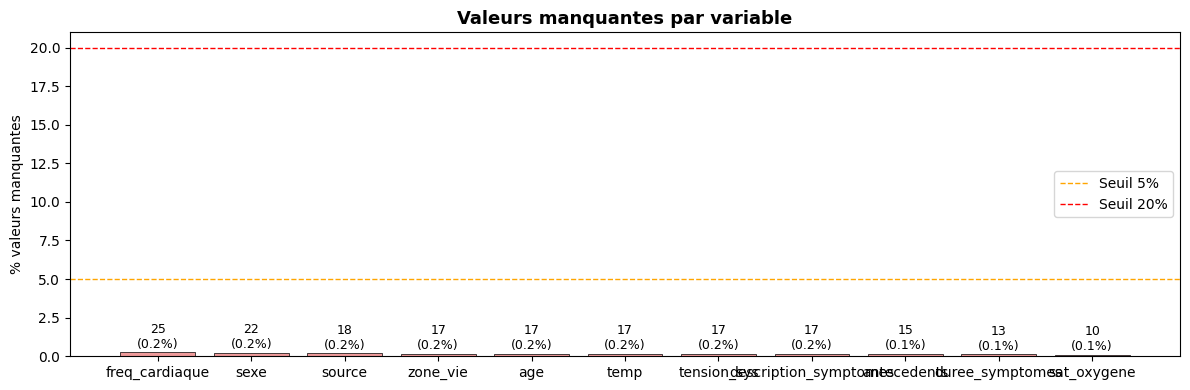


Total NA : 188 sur 131040 valeurs (0.14%)


In [2]:
# Je vérifie si les données ont des valeurs manquantes avant de choisir la stratégie de preprocessing.
# Des trous importants nécessitent une attention particulière ; peu de NA → imputation simple suffisante.

df_eda    = pd.read_csv(_DATA_PATH)
num_c_eda = [c for c in _NUM_COL if c in df_eda.columns]
cat_c_eda = [c for c in _CAT_COL if c in df_eda.columns]

missing     = df_eda.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_eda) * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 4))

if missing.sum() == 0:
    # Si aucune valeur manquante, je l'indique clairement plutôt que d'afficher un graphe vide
    ax.text(0.5, 0.5, "Aucune valeur manquante detectee",
            ha="center", va="center", fontsize=14, color="green")
    ax.axis("off")
else:
    cols_na = missing[missing > 0]
    pct_na  = missing_pct[missing > 0]
    bars = ax.bar(cols_na.index, pct_na.values,
                  color="#ef9a9a", edgecolor="black", lw=0.5)
    for bar, n in zip(bars, cols_na.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{n}\n({bar.get_height():.1f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("% valeurs manquantes")
    # Seuils de référence pour décider la stratégie d'imputation
    ax.axhline(5,  color="orange", ls="--", lw=1, label="Seuil 5%")
    ax.axhline(20, color="red",    ls="--", lw=1, label="Seuil 20%")
    ax.legend()

ax.set_title("Valeurs manquantes par variable", fontsize=13, fontweight="bold")
plt.tight_layout()
show_fig(fig)

print(
    f"\nTotal NA : {missing.sum()} sur {df_eda.size} valeurs "
    f"({missing.sum() / df_eda.size * 100:.2f}%)"
)


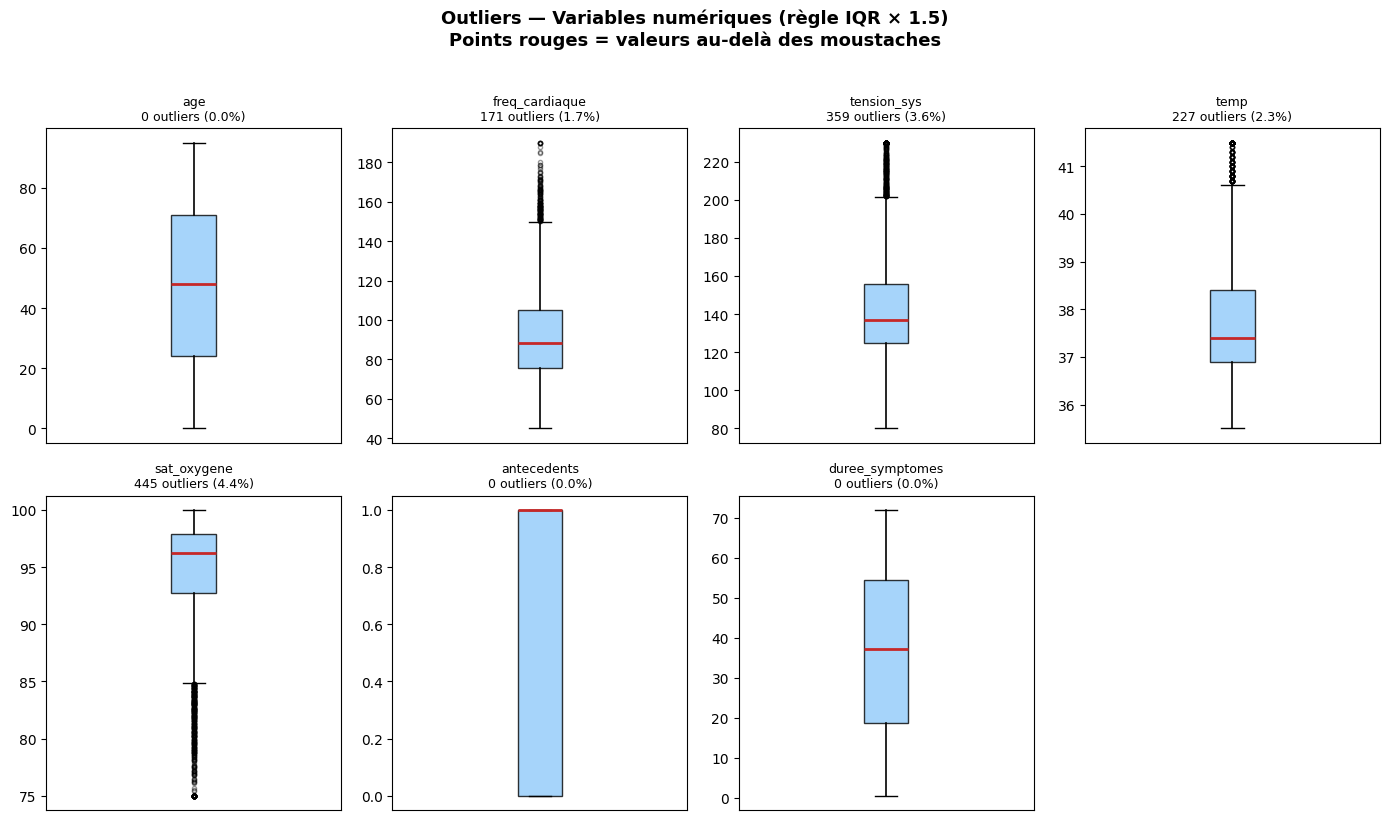

In [3]:
# Je détecte les outliers mais je ne les supprime PAS.
# Une SpO2 à 78% ou une FC à 180 bpm sont des signaux vitaux réels qui
# aident à distinguer les cas urgents — les supprimer effacerait du signal médical.

ncols = 4
nrows = -(-len(num_c_eda) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_c_eda):
    data    = df_eda[col].dropna()
    q1, q3  = data.quantile(0.25), data.quantile(0.75)
    iqr     = q3 - q1
    n_out   = int(((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum())
    pct_out = n_out / len(data) * 100

    axes[i].boxplot(
        data, vert=True, patch_artist=True,
        boxprops    ={"facecolor": "#90caf9", "alpha": 0.8},
        medianprops ={"color": "#c62828", "linewidth": 2},
        flierprops  ={"marker": "o", "markersize": 3, "alpha": 0.4, "color": "#e53935"},
        whiskerprops={"linewidth": 1.2},
    )
    axes[i].set_title(f"{col}\n{n_out} outliers ({pct_out:.1f}%)", fontsize=9)
    axes[i].set_xticks([])

for j in range(len(num_c_eda), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Outliers — Variables numériques (règle IQR × 1.5)\nPoints rouges = valeurs au-delà des moustaches",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
show_fig(fig)


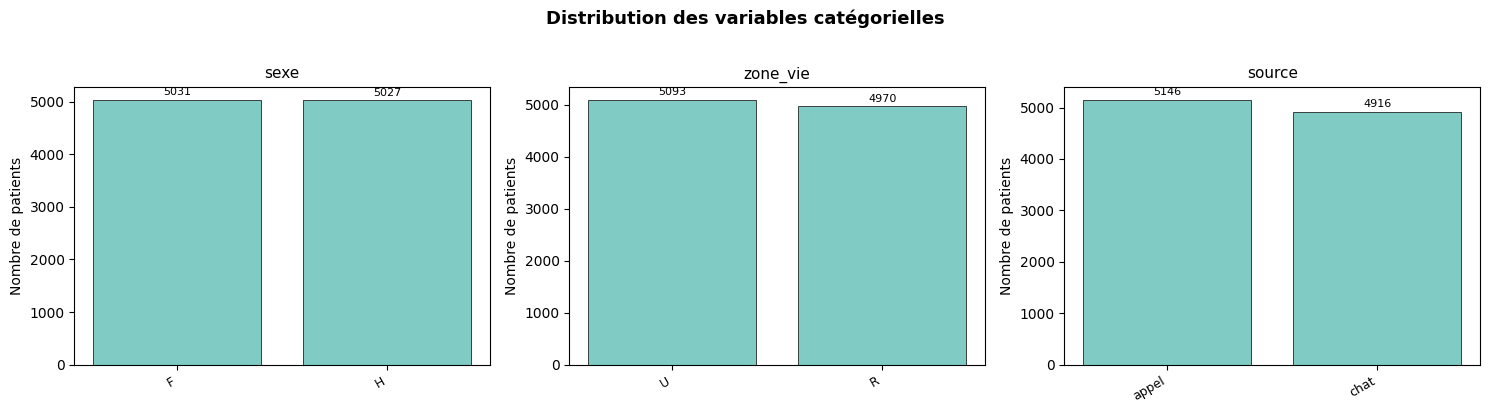

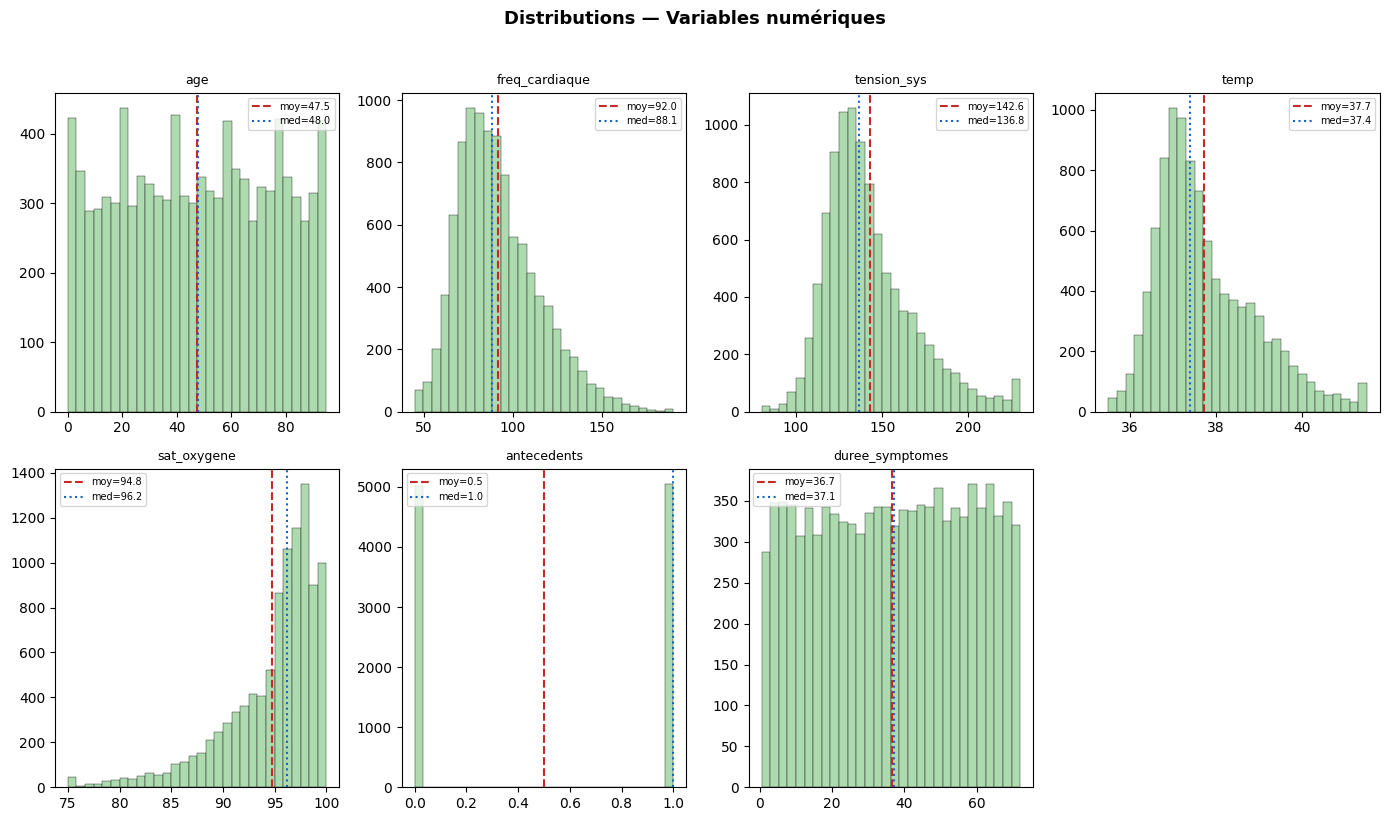

In [4]:
# Je vérifie la répartition des variables catégorielles et numériques.
# Un déséquilibre extrême (ex: 90% d'une modalité) biaiserait l'encodage et l'entraînement.

n_cat = len(cat_c_eda)
fig, axes = plt.subplots(1, n_cat, figsize=(5 * n_cat, 4))
if n_cat == 1:
    axes = [axes]

for ax, col in zip(axes, cat_c_eda):
    vc = df_eda[col].value_counts()
    ax.bar(range(len(vc)), vc.values, color="#80cbc4", edgecolor="black", lw=0.5)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=30, ha="right", fontsize=9)
    for xi, n in enumerate(vc.values):
        ax.text(xi, n + len(df_eda) * 0.005, str(n), ha="center", va="bottom", fontsize=8)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Nombre de patients")

fig.suptitle("Distribution des variables catégorielles", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
show_fig(fig)

# Pour les numériques : quand moyenne et médiane divergent fortement, la distribution est asymétrique.
# C'est pourquoi j'utilise strategy="median" dans le pipeline — la médiane est robuste aux extrêmes.
ncols = 4
nrows = -(-len(num_c_eda) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_c_eda):
    data = df_eda[col].dropna()
    axes[i].hist(data, bins=30, color="#a5d6a7", edgecolor="black", lw=0.3, alpha=0.9)
    axes[i].axvline(data.mean(),   color="#c62828", lw=1.5, ls="--", label=f"moy={data.mean():.1f}")
    axes[i].axvline(data.median(), color="#1565c0", lw=1.5, ls=":",  label=f"med={data.median():.1f}")
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(len(num_c_eda), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distributions — Variables numériques", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
show_fig(fig)


### Synthèse — Ce qu'on retient de l'EDA

**Valeurs manquantes** : très peu de données manquantes sur l'ensemble du dataset. Aucune colonne n'est trop lacunaire pour être utilisée — les imputations (médiane pour le numérique, mode pour le catégoriel) suffisent.

**Outliers** : des valeurs extrêmes sont présentes sur les constantes vitales (fréquence cardiaque très élevée, saturation très basse, etc.). Ces outliers sont **intentionnellement conservés** : ils ne sont pas des erreurs de saisie, ce sont des signaux médicaux forts. Un patient en choc avec une SpO₂ à 78% doit rester dans les données — c'est précisément le type de cas vital que le modèle doit apprendre à détecter.

**Distributions** : les variables numériques présentent des distributions relativement équilibrées autour de leur médiane. Pas de biais de mesure évident.

**Variable texte** : `description_symptomes` est traitée séparément des autres features. Elle ne peut pas passer dans le pipeline tabulaire (imputation + scaling). Elle est vectorisée indépendamment en TF-IDF (500 features, bigrammes) puis concaténée aux features tabulaires avant l'entraînement. C'est ce qui rend le scénario 1 multimodal.

---
## 2. Fonctions communes (partagées par les 4 scénarios)

### `predict_with_thresholds` et seuils asymétriques
Au lieu de l'argmax classique, on classe en vital dès que P(vital) >= 0.15.
Ce mécanisme est indépendant du modèle — il s'applique à toute sortie `predict_proba`.

### `compute_metrics`
Calcule uniquement les 3 métriques médicales + la matrice de confusion normalisée.
Pas de F1 ni d'accuracy : trompeuses dans un contexte de coût asymétrique.

### `run_scenario(X_train, X_test, y_train, y_test, class_weight, thresholds)`
Entraîne les 5 modèles sur les données passées **explicitement en paramètre**.
Le passage explicite évite les confusions entre scénarios (shapes différentes : sparse vs dense).

In [5]:
def predict_with_thresholds(proba, model_classes, thresholds):
    """
    J'abaisse le seuil de détection du niveau vital à 0.15 (contre ~0.33 par défaut).
    Je préfère classer à tort un non-urgent comme vital plutôt que de rater un vrai cas vital.
    L'ordre de priorité reflète la contrainte métier : vital > urgent > non-urgent.
    """
    idx   = {cls: i for i, cls in enumerate(model_classes)}
    preds = []
    for p in proba:
        # J'interroge le niveau vital en premier : mieux vaut sur-classer que sous-classer
        if p[idx[2]] >= thresholds[2]:
            preds.append(2)
        elif p[idx[1]] >= thresholds[1]:
            preds.append(1)
        else:
            preds.append(0)
    return np.array(preds)


def predict_fn(proba, model_classes, thresholds):
    """
    Avec pénalisation (thresholds fourni) : seuils abaissés asymétriques.
    Sans pénalisation (thresholds=None) : argmax standard, le modèle choisit la classe la plus probable.
    """
    if thresholds is not None:
        return predict_with_thresholds(proba, model_classes, thresholds)
    idx_to_cls = {i: cls for i, cls in enumerate(model_classes)}
    return np.array([idx_to_cls[np.argmax(p)] for p in proba])


def compute_metrics(model_name, y_true, y_pred, is_penalized):
    """
    Je n'utilise pas l'accuracy : sur 3 classes déséquilibrées, un modèle qui ignore les cas vitaux
    peut quand même avoir 80% d'accuracy. Je retiens le recall (détecter les vrais cas)
    et la précision (valider les alarmes) par classe, plus la matrice de confusion.
    """
    prec_pc = precision_score(y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    rec_pc  = recall_score   (y_true, y_pred, average=None, labels=CLASSES, zero_division=0)
    cm      = confusion_matrix(y_true, y_pred, labels=CLASSES, normalize="true")
    return {
        "model_name": model_name,
        "penalized":  is_penalized,
        "par_classe": {
            cls: {
                "precision": float(prec_pc[i]),
                "recall":    float(rec_pc[i]),
            }
            for i, cls in enumerate(CLASSES)
        },
        "confusion_matrix": cm.tolist(),
    }


In [6]:
def build_neural_network(input_dim):
    """
    Réseau de neurones dense à 2 couches cachées.
    Le Dropout (30%) évite le sur-apprentissage en désactivant aléatoirement des neurones.
    La sortie Softmax donne 3 probabilités qui somment à 1, une par niveau d'urgence.
    """
    model = keras.Sequential([
        keras.layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(3, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


class NNWrapper:
    """Adaptateur pour utiliser le réseau Keras avec les mêmes fonctions que les modèles sklearn."""
    def __init__(self, model):
        self.model    = model
        self.classes_ = np.array([0, 1, 2])

    def predict_proba(self, X):
        # Le réseau exige des données denses — je convertis si nécessaire
        X_d = X.toarray() if hasattr(X, "toarray") else np.asarray(X)
        return self.model.predict(X_d, verbose=0)


def run_scenario(X_train, X_test, y_train, y_test, class_weight, thresholds):
    """
    Entraîne tous les modèles sur un scénario et compare leurs performances.
    Je lance deux configurations : avec pénalisation (class_weight + seuils abaissés)
    et sans pénalisation (comportement naturel des modèles, argmax standard).
    """
    is_penalized = class_weight is not None
    # XGBoost gère la pénalisation via sample_weight (pas class_weight comme les autres)
    xgb_sw = np.array([class_weight[int(y)] for y in y_train]) if class_weight else None

    # Les 4 modèles comparés dans ce benchmark
    sklearn_models = [
        ("LogisticRegression", LogisticRegression(
            max_iter=1000, class_weight=class_weight, random_state=RANDOM_STATE,
        )),
        ("RandomForest", RandomForestClassifier(
            n_estimators=200, class_weight=class_weight,
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
        ("XGBoost", XGBClassifier(
            n_estimators=200, eval_metric="mlogloss",
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        )),
        ("LightGBM", LGBMClassifier(
            n_estimators=200, class_weight=class_weight,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )),
    ]

    all_results, all_profiles = [], []

    for model_name, model in sklearn_models:
        print(f"  [{model_name}]", end=" ", flush=True)
        t0 = time.perf_counter()
        if model_name == "XGBoost" and xgb_sw is not None:
            model.fit(X_train, y_train, sample_weight=xgb_sw)
        else:
            model.fit(X_train, y_train)
        train_time = time.perf_counter() - t0

        proba  = model.predict_proba(X_test)
        y_pred = predict_fn(proba, list(model.classes_), thresholds)
        result = compute_metrics(model_name, y_test, y_pred, is_penalized)

        # Validation croisée : je mesure la stabilité du recall vital sur N_FOLDS folds
        # Je clone le modèle pour ne pas modifier celui entraîné sur le train complet
        cv_obj = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        cv_recalls2 = []
        for tr_idx, val_idx in cv_obj.split(X_train, y_train):
            X_cv_tr  = X_train[tr_idx]
            X_cv_val = X_train[val_idx]
            y_cv_tr  = y_train.iloc[tr_idx]
            y_cv_val = y_train.iloc[val_idx]
            m_clone  = clone(model)
            if model_name == "XGBoost" and xgb_sw is not None:
                fold_sw = np.array([class_weight[int(y)] for y in y_cv_tr])
                m_clone.fit(X_cv_tr, y_cv_tr, sample_weight=fold_sw)
            else:
                m_clone.fit(X_cv_tr, y_cv_tr)
            fold_proba = m_clone.predict_proba(X_cv_val)
            fold_pred  = predict_fn(fold_proba, list(m_clone.classes_), thresholds)
            cv_recalls2.append(
                recall_score(y_cv_val, fold_pred, labels=[2], average=None, zero_division=0)[0]
            )
        cv_recall2_mean = float(np.mean(cv_recalls2))
        cv_recall2_std  = float(np.std(cv_recalls2))
        print(f"    CV Recall cl.2 ({N_FOLDS} folds) : {cv_recall2_mean:.3f} ± {cv_recall2_std:.3f}")

        result["cv_recall2_mean"] = round(cv_recall2_mean, 4)
        result["cv_recall2_std"]  = round(cv_recall2_std, 4)
        all_results.append(result)

        profile = profile_model(
            model_name=model_name,
            predict_fn=lambda X, m=model: predict_fn(
                m.predict_proba(X), list(m.classes_), thresholds
            ),
            X_test=X_test,
        )
        profile["train_time_s"] = round(train_time, 4)
        all_profiles.append(profile)
        print("OK")

    # ── Réseau de neurones ───────────────────────────────────────────────
    print("  [NeuralNetwork]", end=" ", flush=True)
    # Le réseau Keras exige des données denses — je convertis la matrice creuse
    X_tr_d = X_train.toarray() if hasattr(X_train, "toarray") else np.asarray(X_train)
    X_te_d = X_test.toarray()  if hasattr(X_test,  "toarray") else np.asarray(X_test)

    nn = build_neural_network(X_tr_d.shape[1])
    t0 = time.perf_counter()
    nn.fit(
        X_tr_d, y_train,
        epochs=100, batch_size=64, validation_split=0.1,
        class_weight=class_weight,
        callbacks=[EarlyStopping(
            monitor="val_loss", patience=10,
            restore_best_weights=True, verbose=0,
        )],
        verbose=0,
    )
    nn_train = time.perf_counter() - t0

    nn_proba  = nn.predict(X_te_d, verbose=0)
    nn_y_pred = predict_fn(nn_proba, [0, 1, 2], thresholds)
    result_nn = compute_metrics("NeuralNetwork", y_test, nn_y_pred, is_penalized)
    result_nn["cv_recall2_mean"] = None  # CV non calculée pour le réseau (trop coûteux en temps)
    result_nn["cv_recall2_std"]  = None
    all_results.append(result_nn)

    nn_w = NNWrapper(nn)
    profile_nn = profile_model(
        model_name="NeuralNetwork",
        predict_fn=lambda X: predict_fn(nn_w.predict_proba(X), [0, 1, 2], thresholds),
        X_test=X_test,
    )
    profile_nn["train_time_s"] = round(nn_train, 4)
    all_profiles.append(profile_nn)
    print("OK")

    return all_results, all_profiles


---
## 3. Fonctions de visualisation

Trois fonctions générées **par scénario** :

- **`plot_medical_metrics`** : 3 sous-graphiques (recall_2 fond rose, recall_1, précision_0).
  Barres côte à côte avec/sans pénalisation. Valeurs annotées, seuil 0.80 en pointillés.

- **`plot_confusions`** : grille 2 lignes (avec/sans) × 5 modèles.
  Taux normalisé par classe réelle — lire par ligne : que devient la classe X ?

- **`plot_resources`** : tableau temps d'entraînement, latence/échantillon, RAM.

Quatre fonctions pour la **comparaison cross-scénarios** :

- **`plot_cross_scenario`** : recall_2 et recall_1 tous modèles × scénarios.
- **`plot_cross_precision0`** : précision classe 0 cross-scénarios.
- **`plot_cross_resources`** : tableau ressources global.
- **`plot_cross_confusions`** : grille 4 scénarios × 5 modèles — vue d'ensemble des erreurs par classe pour tous les scénarios en un seul graphique.

In [7]:
def plot_medical_metrics(results_avec, results_sans, title):
    """
    Compare les performances avec et sans pénalisation pour chaque modèle.
    Les métriques sont ordonnées par priorité médicale : vital d'abord, urgent ensuite.
    """
    models = [r["model_name"] for r in results_avec]
    x, w   = np.arange(len(models)), 0.35
    cfg = [
        (2, "recall",    "Recall — Classe 2 (Vital)\npriorite absolue : eviter le sous-triage", "#c62828"),
        (1, "recall",    "Recall — Classe 1 (Urgent)",                                           "#e65100"),
        (0, "precision", "Precision — Classe 0 (Pas urgent)\nquand on dit 'pas urgent', est-on sur ?", "#1565c0"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Metriques medicales — {title}", fontsize=14, y=1.02, fontweight="bold")
    for ax, (cls, key, subtitle, color) in zip(axes, cfg):
        v_a = [r["par_classe"][cls][key] for r in results_avec]
        v_s = [r["par_classe"][cls][key] for r in results_sans]
        b1 = ax.bar(x - w/2, v_a, w, color=color, alpha=0.90,
                    hatch="//", edgecolor="black", lw=0.5, label="Avec penalisation *")
        b2 = ax.bar(x + w/2, v_s, w, color=color, alpha=0.35,
                    edgecolor="black", lw=0.5, label="Sans penalisation")
        for bar in list(b1) + list(b2):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.013,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=7.5)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=28, ha="right", fontsize=9)
        ax.set_ylim(0, 1.22)
        ax.axhline(0.80, color="gray", ls="--", lw=0.9, alpha=0.6, label="Seuil 0.80")
        ax.set_title(subtitle, fontsize=10, pad=8)
        ax.legend(fontsize=8, loc="lower right")
        # Le fond rouge rappelle que le recall vital est la métrique la plus critique
        if cls == 2 and key == "recall":
            ax.set_facecolor("#fff5f5")
    plt.tight_layout()
    show_fig(fig)


def plot_confusions(results_avec, results_sans, title):
    """
    Matrices de confusion normalisées : je lis par ligne.
    La diagonale = ce qui est bien classé. Hors diagonale = les erreurs.
    Je compare avec et sans pénalisation pour mesurer l'impact sur les sous-triages.
    """
    n         = len(results_avec)
    fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 9))
    for col, (r_a, r_s) in enumerate(zip(results_avec, results_sans)):
        for row, (r, row_lbl) in enumerate(
            [(r_a, "Avec penalisation"), (r_s, "Sans penalisation")]
        ):
            ax   = axes[row][col]
            cm   = np.array(r["confusion_matrix"])
            disp = ConfusionMatrixDisplay(cm, display_labels=["Non-urg.", "Urgent", "Vital"])
            disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
            ax.set_title(f"{r['model_name']}\n{row_lbl}", fontsize=9, pad=5)
            plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
            plt.setp(ax.get_yticklabels(), fontsize=8)
    fig.suptitle(f"Matrices de confusion — {title}", fontsize=13, y=1.01)
    plt.tight_layout()
    show_fig(fig)


def plot_resources(profiles_avec, title):
    """
    Un modèle trop lent ou trop gourmand en RAM n'est pas déployable en télémédecine.
    Je compare latence par patient, temps d'entraînement et RAM au pic.
    """
    col_labels = ["Modele", "Entrainement (s)", "Inference / ech. (ms)", "RAM pic (MB)"]
    cell_vals  = [[
        p["model_name"],
        f"{p['train_time_s']:.2f}" if p["train_time_s"] is not None else "-",
        f"{p['inference_time_per_sample_ms']:.4f}",
        f"{p['ram_inference_peak_mb']:.2f}",
    ] for p in profiles_avec]
    fig, ax = plt.subplots(figsize=(11, 0.7 * (len(cell_vals) + 2)))
    ax.axis("off")
    tbl = ax.table(cellText=cell_vals, colLabels=col_labels, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.9)
    ax.set_title(f"Ressources — {title} (avec penalisation)", fontsize=12, pad=14)
    plt.tight_layout()
    show_fig(fig)


In [8]:
def plot_cross_scenario(all_results, config_label="avec penalisation"):
    """
    Je compare les 4 scénarios sur les mêmes modèles pour voir si retirer des variables
    dégrade les performances. Si S2 ≈ S1, je peux me passer de sexe et zone_vie sans perte.
    """
    scenarios = list(all_results.keys())
    models    = [r["model_name"] for r in list(all_results.values())[0]]
    n_sc      = len(scenarios)
    colors    = ["#1565c0", "#558b2f", "#e65100", "#6a1b9a"][:n_sc]
    x, w      = np.arange(len(models)), 0.18
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Comparaison cross-scenarios — {config_label}", fontsize=14, fontweight="bold")
    for ax, (cls, key, subtitle) in zip(axes, [
        (2, "recall", "Recall classe 2 (Vital)\nplus haut = moins de sous-triages"),
        (1, "recall", "Recall classe 1 (Urgent)"),
    ]):
        for i, (scenario, results) in enumerate(all_results.items()):
            vals   = [r["par_classe"][cls][key] for r in results]
            offset = (i - n_sc / 2 + 0.5) * w
            bars   = ax.bar(x + offset, vals, w, label=scenario,
                            color=colors[i], edgecolor="black", lw=0.5, alpha=0.85)
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                        f"{h:.2f}", ha="center", va="bottom", fontsize=6, rotation=60)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=25, ha="right", fontsize=9)
        ax.set_ylim(0, 1.32)
        ax.axhline(0.80, color="gray", ls="--", lw=0.9, alpha=0.6)
        ax.set_title(subtitle, fontsize=11)
        ax.legend(fontsize=8)
        if cls == 2:
            ax.set_facecolor("#fff5f5")
    plt.tight_layout()
    show_fig(fig)


def plot_cross_precision0(all_results, config_label="avec penalisation"):
    """
    Si on prédit "pas urgent" à tort, un patient vital risque de ne pas être pris en charge.
    Cette métrique est une mesure de sécurité : je vérifie que mes "fausses alarmes négatives" restent rares.
    """
    scenarios = list(all_results.keys())
    models    = [r["model_name"] for r in list(all_results.values())[0]]
    n_sc      = len(scenarios)
    colors    = ["#1565c0", "#558b2f", "#e65100", "#6a1b9a"][:n_sc]
    x, w      = np.arange(len(models)), 0.18
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_title(
        f"Precision classe 0 (Pas urgent) — Cross-scenarios, {config_label}\n"
        "Quand on dit 'pas urgent', est-on vraiment sur ?",
        fontsize=12, fontweight="bold",
    )
    for i, (scenario, results) in enumerate(all_results.items()):
        vals   = [r["par_classe"][0]["precision"] for r in results]
        offset = (i - n_sc / 2 + 0.5) * w
        ax.bar(x + offset, vals, w, label=scenario,
               color=colors[i], edgecolor="black", lw=0.5, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right")
    ax.set_ylim(0, 1.15)
    ax.axhline(0.80, color="gray", ls="--", lw=0.9, alpha=0.6)
    ax.legend(fontsize=9)
    plt.tight_layout()
    show_fig(fig)


def plot_cross_resources(all_profiles_avec):
    """
    Je vérifie si les scénarios plus complexes (multimodal + TF-IDF) sont significativement
    plus lents ou plus lourds que les scénarios allégés.
    """
    col_labels = ["Scenario", "Modele", "Entrainement (s)", "Inference / ech. (ms)", "RAM pic (MB)"]
    cell_vals = []
    for scenario, profiles in all_profiles_avec.items():
        for p in profiles:
            cell_vals.append([
                scenario, p["model_name"],
                f"{p['train_time_s']:.2f}" if p["train_time_s"] is not None else "-",
                f"{p['inference_time_per_sample_ms']:.4f}",
                f"{p['ram_inference_peak_mb']:.2f}",
            ])
    fig, ax = plt.subplots(figsize=(14, 0.50 * (len(cell_vals) + 2)))
    ax.axis("off")
    tbl = ax.table(cellText=cell_vals, colLabels=col_labels, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    ax.set_title("Ressources — Comparaison cross-scenarios (avec penalisation)", fontsize=12, pad=14)
    plt.tight_layout()
    show_fig(fig)


def plot_cross_confusions(all_results, config_label="avec penalisation"):
    """
    Grille complète : je regarde où chaque scénario fait ses erreurs.
    Est-ce que S3 (NLP seul) confond davantage les cas vitaux que S1 (multimodal) ?
    """
    scenarios = list(all_results.keys())
    models    = [r["model_name"] for r in list(all_results.values())[0]]
    n_sc, n_mod = len(scenarios), len(models)
    fig, axes = plt.subplots(n_sc, n_mod, figsize=(4.5 * n_mod, 4 * n_sc))
    fig.suptitle(
        f"Matrices de confusion — Comparaison cross-scenarios ({config_label})\n"
        "Lire par ligne : que devient chaque classe reelle ?",
        fontsize=13, fontweight="bold", y=1.01,
    )
    for row, scenario in enumerate(scenarios):
        for col, model_name in enumerate(models):
            ax     = axes[row][col]
            result = next(r for r in all_results[scenario] if r["model_name"] == model_name)
            cm     = np.array(result["confusion_matrix"])
            disp   = ConfusionMatrixDisplay(cm, display_labels=["Non-urg.", "Urgent", "Vital"])
            disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
            if col == 0:
                ax.set_ylabel(f"{scenario}\n{ax.get_ylabel()}", fontsize=8)
            if row == 0:
                ax.set_title(model_name, fontsize=10, fontweight="bold")
            else:
                ax.set_title("")
            plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=7)
            plt.setp(ax.get_yticklabels(), fontsize=7)
    plt.tight_layout()
    show_fig(fig)


---
## 4. Scénario 1 — Multimodal complet

**Données utilisées :** toutes les colonnes disponibles.

- **Variables tabulaires :** âge, constantes vitales (FC, TA, température, SpO2),
  antécédents, durée des symptômes, sexe, zone de vie, source de contact
- **Texte :** `description_symptomes` vectorisé en TF-IDF (500 features, bigrammes)

**Pourquoi c'est le scénario de référence :**
Il exploite l'intégralité de l'information disponible = **plafond de performance attendu**.
Si un autre scénario atteint des scores proches, on peut se passer des données supprimées.

In [9]:
# Scénario 1 — Multimodal complet : j'utilise toutes les données disponibles.
# C'est mon scénario de référence — les autres scénarios retireront progressivement des variables.
# Tabulaire et TF-IDF (texte) sont fusionnés en matrice creuse avant l'entraînement.
df_s1  = pd.read_csv(_DATA_PATH)
df_s1  = apply_business_rules(df_s1)

# Filtrer les colonnes réellement présentes dans le dataset
num_s1 = [c for c in _NUM_COL if c in df_s1.columns]
cat_s1 = [c for c in _CAT_COL if c in df_s1.columns]

# Je fais le split avant tout fit : aucune information du test ne doit contaminer l'entraînement
# stratify=TARGET garantit que les 3 classes sont représentées proportionnellement dans chaque partie
train_s1, test_s1 = train_test_split(
    df_s1, test_size=0.2, random_state=RANDOM_STATE, stratify=df_s1[TARGET]
)
train_s1 = train_s1.reset_index(drop=True)
test_s1  = test_s1.reset_index(drop=True)

# Je fitte le preprocessing uniquement sur le train — jamais sur le test
X_tab_tr_s1, y_tr_s1, prep_s1, _ = preprocessingTechnique(
    train_s1.drop(columns=[TEXT_COL], errors="ignore"),
    target_col=TARGET, num_cols=num_s1, cat_cols=cat_s1, to_drop=_TRASH,
)

X_tab_te_s1 = prep_s1.transform(
    test_s1.drop(columns=_TRASH + [TARGET, TEXT_COL], errors="ignore")
)
y_te_s1 = test_s1[TARGET].reset_index(drop=True)

# TF-IDF : je vectorise le texte en 500 features bigrammes, fit sur le train uniquement
tfidf_s1    = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_txt_tr_s1 = tfidf_s1.fit_transform(train_s1[TEXT_COL].fillna(""))
X_txt_te_s1 = tfidf_s1.transform(test_s1[TEXT_COL].fillna(""))

# Je fusionne la partie tabulaire et la partie TF-IDF en une seule matrice creuseSR : Compressed Sparse Row, efficient)
X_tr_s1 = sp.hstack([sp.csr_matrix(X_tab_tr_s1.values), X_txt_tr_s1], format="csr")
X_te_s1 = sp.hstack([sp.csr_matrix(X_tab_te_s1),        X_txt_te_s1], format="csr")
print(f"S1 — train: {X_tr_s1.shape}, test: {X_te_s1.shape}")


     RAPPORT RÈGLES MÉTIERS
  • Doublons complets supprimés : 77 ligne(s) (10080 → 10003)
        RAPPORT DE PREPROCESSING
  • Colonnes supprimées (1) : ['patient_id']
  • Colonnes numériques fournies (7) : ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'antecedents', 'duree_symptomes']
  • Colonnes catégorielles fournies (3) : ['sexe', 'zone_vie', 'source']
  • Numériques → imputation médiane + MinMaxScaler
  • Catégorielles → imputation mode + OneHotEncoder
  • Valeurs manquantes avant : 137 → après : 0
  • Dimensions avant  : (8002, 10)
  • Dimensions après  : (8002, 13)
S1 — train: (8002, 513), test: (2001, 513)


In [10]:
# Scénario 1 — Entraînement avec et sans pénalisation.
# J'entraîne chaque modèle deux fois pour mesurer l'impact de la pénalisation asymétrique.

# Avec pénalisation
print("=" * 55 + "\n  S1 - COMPLET — AVEC PENALISATION\n" + "=" * 55)
res_avec_s1, prof_avec_s1 = run_scenario(
    X_tr_s1, X_te_s1, y_tr_s1, y_te_s1, CLASS_WEIGHT, THRESHOLDS
)

# Sans pénalisation : comportement naturel du modèle, argmax sur les probabilités
print("\n" + "=" * 55 + "\n  S1 - COMPLET — SANS PENALISATION\n" + "=" * 55)
res_sans_s1, _ = run_scenario(
    X_tr_s1, X_te_s1, y_tr_s1, y_te_s1, None, None
)

# Je stocke les résultats pour les comparer ensuite avec les autres scénarios
ALL_RESULTS_AVEC["S1 - Complet"] = res_avec_s1
ALL_PROFILES_AVEC["S1 - Complet"] = prof_avec_s1
ALL_RESULTS_SANS["S1 - Complet"] = res_sans_s1


  S1 - COMPLET — AVEC PENALISATION
  [LogisticRegression]     CV Recall cl.2 (5 folds) : 0.971 ± 0.008
  PROFILING : LogisticRegression
  Inférence totale       : 0.000987 s  (médiane 10 runs)
  Inférence / échantillon: 0.0005 ms
  RAM inférence (peak)   : 0.14 MB
  CPU inférence          : 0.0 %
OK
  [RandomForest]     CV Recall cl.2 (5 folds) : 0.970 ± 0.006
  PROFILING : RandomForest
  Inférence totale       : 0.071308 s  (médiane 10 runs)
  Inférence / échantillon: 0.0356 ms
  RAM inférence (peak)   : 1.19 MB
  CPU inférence          : 140.2 %
OK
  [XGBoost]     CV Recall cl.2 (5 folds) : 0.936 ± 0.011
  PROFILING : XGBoost
  Inférence totale       : 0.014424 s  (médiane 10 runs)
  Inférence / échantillon: 0.0072 ms
  RAM inférence (peak)   : 0.06 MB
  CPU inférence          : 1145.8 %
OK
  [LightGBM]     CV Recall cl.2 (5 folds) : 0.939 ± 0.014
  PROFILING : LightGBM
  Inférence totale       : 0.024252 s  (médiane 10 runs)
  Inférence / échantillon: 0.0121 ms
  RAM inférence (peak

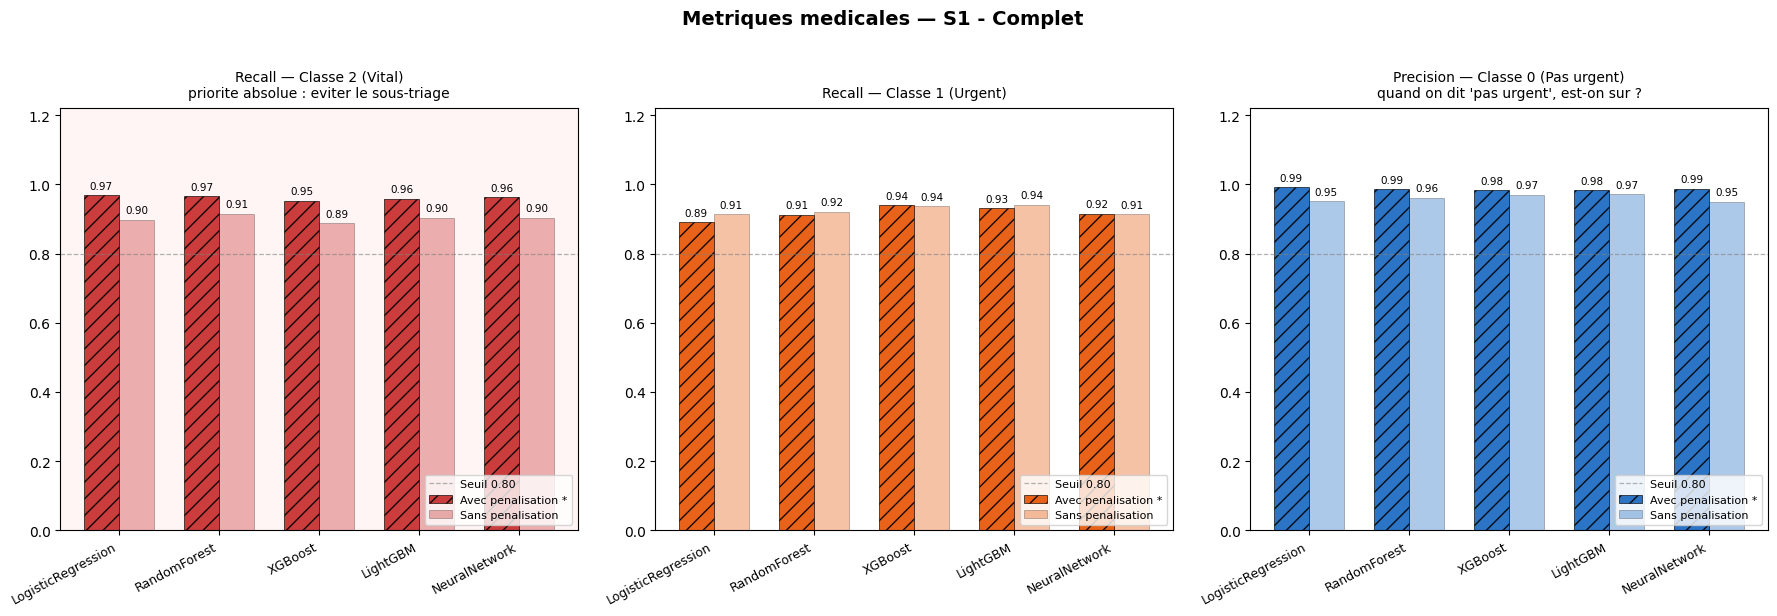

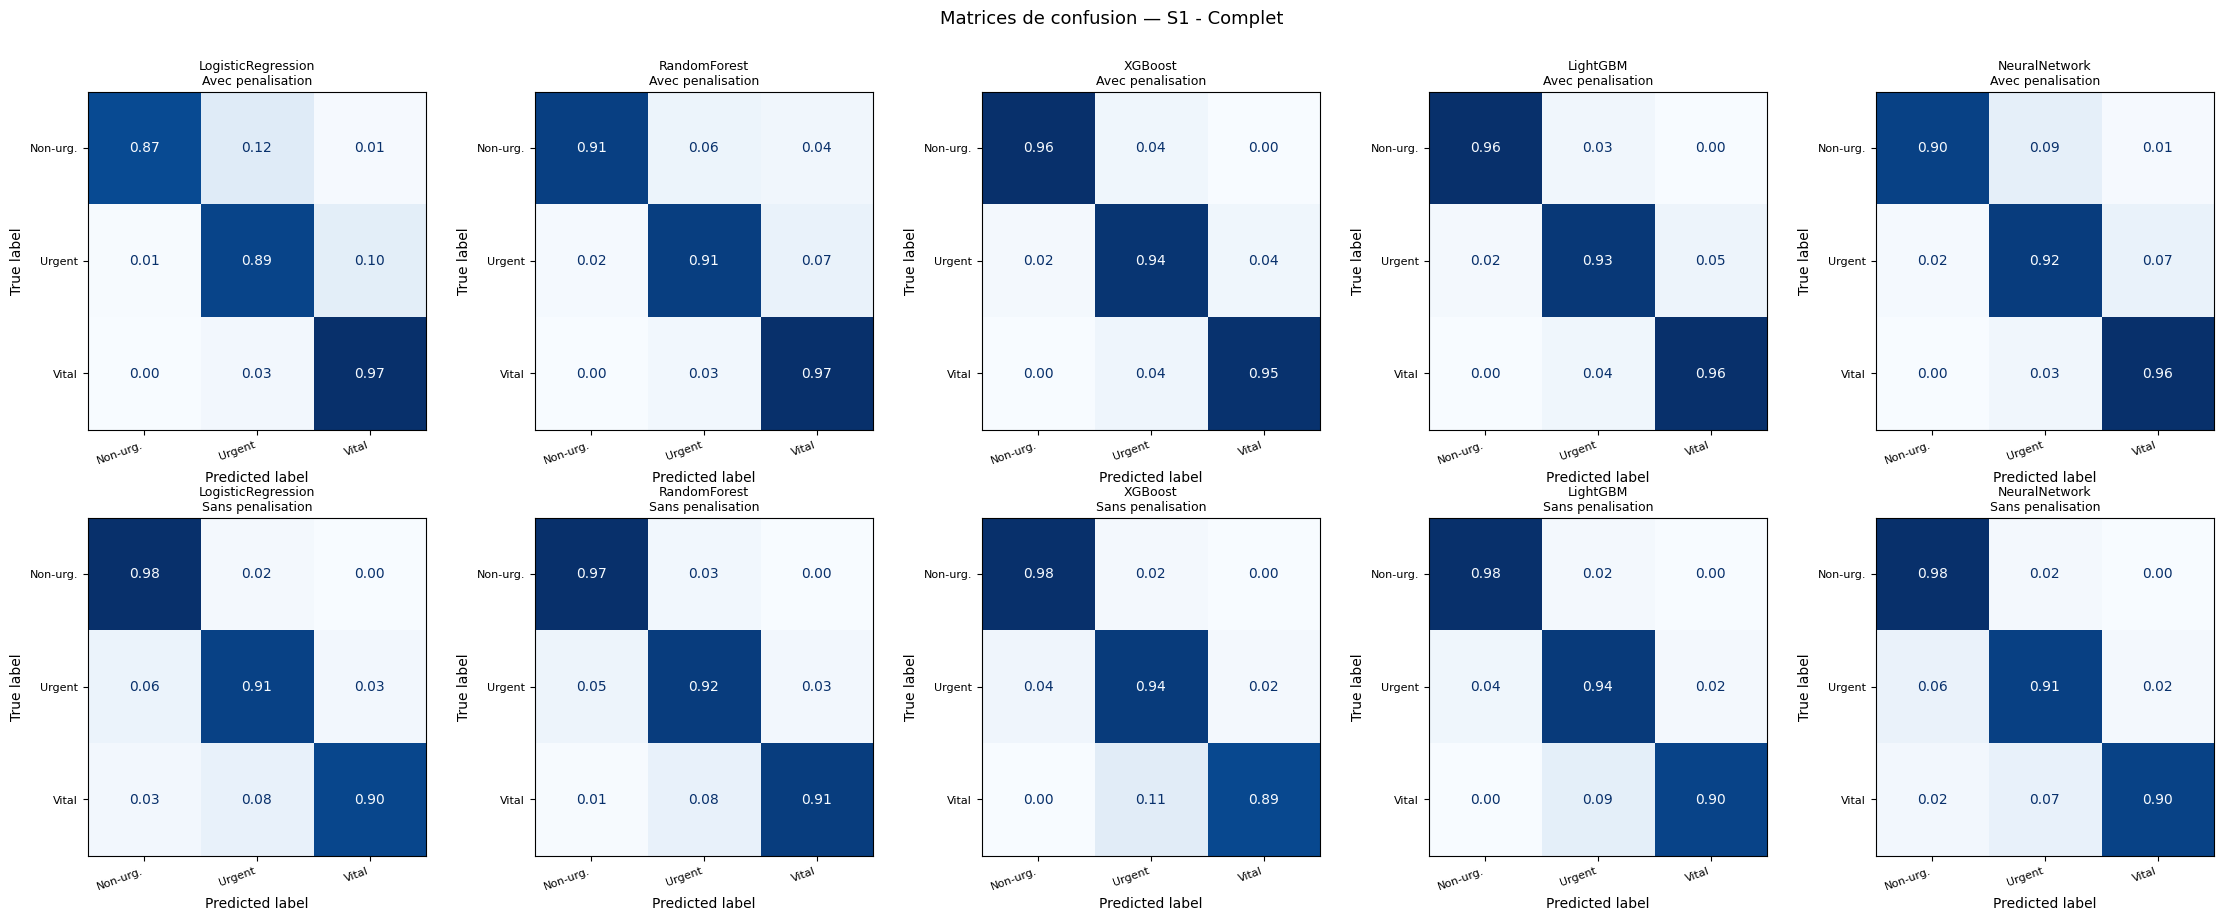

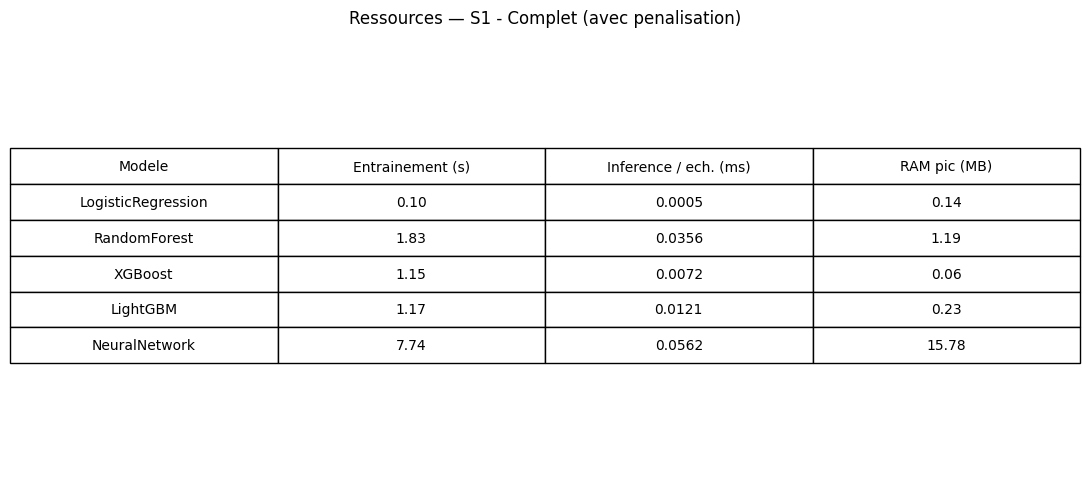

In [11]:
# Scénario 1 — Visualisation des résultats : métriques médicales, matrices de confusion, ressources.

plot_medical_metrics(res_avec_s1, res_sans_s1, "S1 - Complet")
plot_confusions(res_avec_s1, res_sans_s1, "S1 - Complet")
plot_resources(prof_avec_s1, "S1 - Complet")


---
## 5. Scénario 2 — Éthique / Sans variables sensibles

**Données utilisées :** même chose que S1, sauf :
- `sexe` et `zone_vie` **supprimés** (risque de biais discriminatoire, RGPD)
- `age` **discrétisé** en tranches médicales (`enfant / adulte_jeune / adulte / senior`)

**Question :** peut-on atteindre des performances similaires à S1 sans les variables sensibles ?

**Enjeu :** un modèle équitable ne doit pas produire des résultats qui varient selon
le sexe ou la zone géographique du patient. Si S2 ≈ S1, on peut déployer S2
avec une meilleure garantie éthique et de conformité RGPD.

In [12]:
# Scénario 2 — Éthique : je retire sexe et zone_vie (conformité RGPD + biais potentiel).
# Je remplace l'âge précis par une tranche médicale pour réduire le risque de ré-identification.
# Question clé : est-ce que retirer ces variables dégrade les performances ?

df_s2 = pd.read_csv(_DATA_PATH)
df_s2 = apply_business_rules(df_s2)

# Le preprocessing éthique supprime les variables sensibles et discrétise l'âge
df_s2 = ethical_preprocessing(df_s2, sensitive_cols=["sexe", "zone_vie"])

# Après discrétisation, l'âge devient une catégorie — je l'encode avec OneHot
num_s2 = [c for c in _NUM_COL if c in df_s2.columns and c != "age"]
cat_s2 = [c for c in _CAT_COL if c in df_s2.columns] + ["age"]

train_s2, test_s2 = train_test_split(
    df_s2, test_size=0.2, random_state=RANDOM_STATE, stratify=df_s2[TARGET]
)
train_s2 = train_s2.reset_index(drop=True)
test_s2  = test_s2.reset_index(drop=True)

X_tab_tr_s2, y_tr_s2, prep_s2, _ = preprocessingTechnique(
    train_s2.drop(columns=[TEXT_COL], errors="ignore"),
    target_col=TARGET, num_cols=num_s2, cat_cols=cat_s2, to_drop=_TRASH,
)
X_tab_te_s2 = prep_s2.transform(
    test_s2.drop(columns=_TRASH + [TARGET, TEXT_COL], errors="ignore")
)
y_te_s2 = test_s2[TARGET].reset_index(drop=True)

tfidf_s2    = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_txt_tr_s2 = tfidf_s2.fit_transform(train_s2[TEXT_COL].fillna(""))
X_txt_te_s2 = tfidf_s2.transform(test_s2[TEXT_COL].fillna(""))

X_tr_s2 = sp.hstack([sp.csr_matrix(X_tab_tr_s2.values), X_txt_tr_s2], format="csr")
X_te_s2 = sp.hstack([sp.csr_matrix(X_tab_te_s2),        X_txt_te_s2], format="csr")
print(f"S2 — train: {X_tr_s2.shape}, test: {X_te_s2.shape}")


     RAPPORT RÈGLES MÉTIERS
  • Doublons complets supprimés : 77 ligne(s) (10080 → 10003)
    RAPPORT PREPROCESSING ÉTHIQUE
  • age : généralisation → tranches [enfant | adulte_jeune | adulte | senior]
  • Variables sensibles supprimées : ['sexe', 'zone_vie']
        RAPPORT DE PREPROCESSING
  • Colonnes supprimées (1) : ['patient_id']
  • Colonnes numériques fournies (6) : ['freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'antecedents', 'duree_symptomes']
  • Colonnes catégorielles fournies (2) : ['source', 'age']
  • Numériques → imputation médiane + MinMaxScaler
  • Catégorielles → imputation mode + OneHotEncoder
  • Valeurs manquantes avant : 182 → après : 0
  • Dimensions avant  : (8002, 8)
  • Dimensions après  : (8002, 12)
S2 — train: (8002, 512), test: (2001, 512)


In [13]:
# Scénario 2 — Entraînement.
# Si S2 ≈ S1, c'est la preuve que sexe et zone_vie n'apportaient aucun signal utile.
# On peut déployer le scénario éthique sans compromis sur la qualité du triage.

print("=" * 55 + "\n  S2 - ETHIQUE — AVEC PENALISATION\n" + "=" * 55)
res_avec_s2, prof_avec_s2 = run_scenario(
    X_tr_s2, X_te_s2, y_tr_s2, y_te_s2, CLASS_WEIGHT, THRESHOLDS
)

print("\n" + "=" * 55 + "\n  S2 - ETHIQUE — SANS PENALISATION\n" + "=" * 55)
res_sans_s2, _ = run_scenario(
    X_tr_s2, X_te_s2, y_tr_s2, y_te_s2, None, None
)

ALL_RESULTS_AVEC["S2 - Ethique"] = res_avec_s2
ALL_PROFILES_AVEC["S2 - Ethique"] = prof_avec_s2
ALL_RESULTS_SANS["S2 - Ethique"] = res_sans_s2


  S2 - ETHIQUE — AVEC PENALISATION
  [LogisticRegression]     CV Recall cl.2 (5 folds) : 0.973 ± 0.007
  PROFILING : LogisticRegression
  Inférence totale       : 0.002001 s  (médiane 10 runs)
  Inférence / échantillon: 0.0010 ms
  RAM inférence (peak)   : 0.14 MB
  CPU inférence          : 0.0 %
OK
  [RandomForest]     CV Recall cl.2 (5 folds) : 0.967 ± 0.012
  PROFILING : RandomForest
  Inférence totale       : 0.099011 s  (médiane 10 runs)
  Inférence / échantillon: 0.0495 ms
  RAM inférence (peak)   : 1.16 MB
  CPU inférence          : 186.4 %
OK
  [XGBoost]     CV Recall cl.2 (5 folds) : 0.934 ± 0.014
  PROFILING : XGBoost
  Inférence totale       : 0.014166 s  (médiane 10 runs)
  Inférence / échantillon: 0.0071 ms
  RAM inférence (peak)   : 0.06 MB
  CPU inférence          : 1074.2 %
OK
  [LightGBM]     CV Recall cl.2 (5 folds) : 0.941 ± 0.013
  PROFILING : LightGBM
  Inférence totale       : 0.024058 s  (médiane 10 runs)
  Inférence / échantillon: 0.0120 ms
  RAM inférence (peak

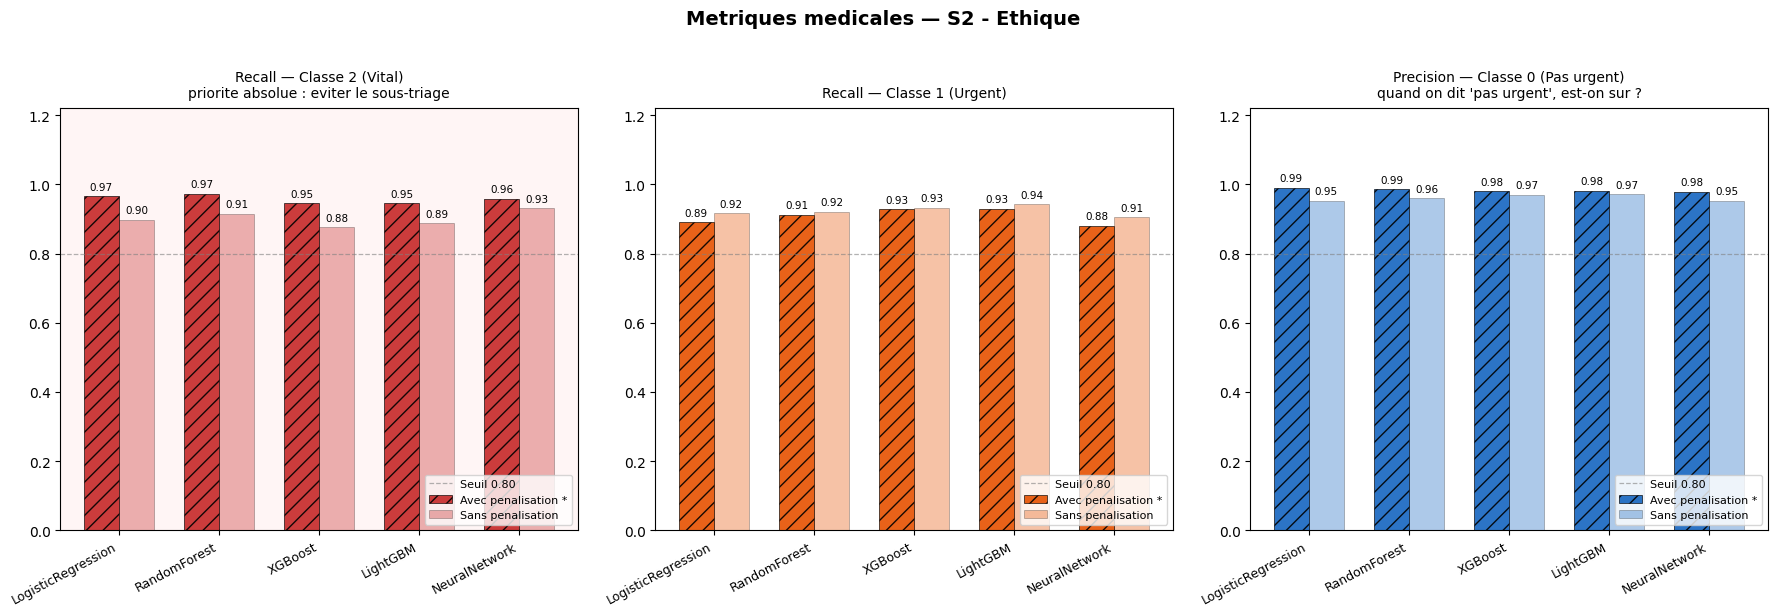

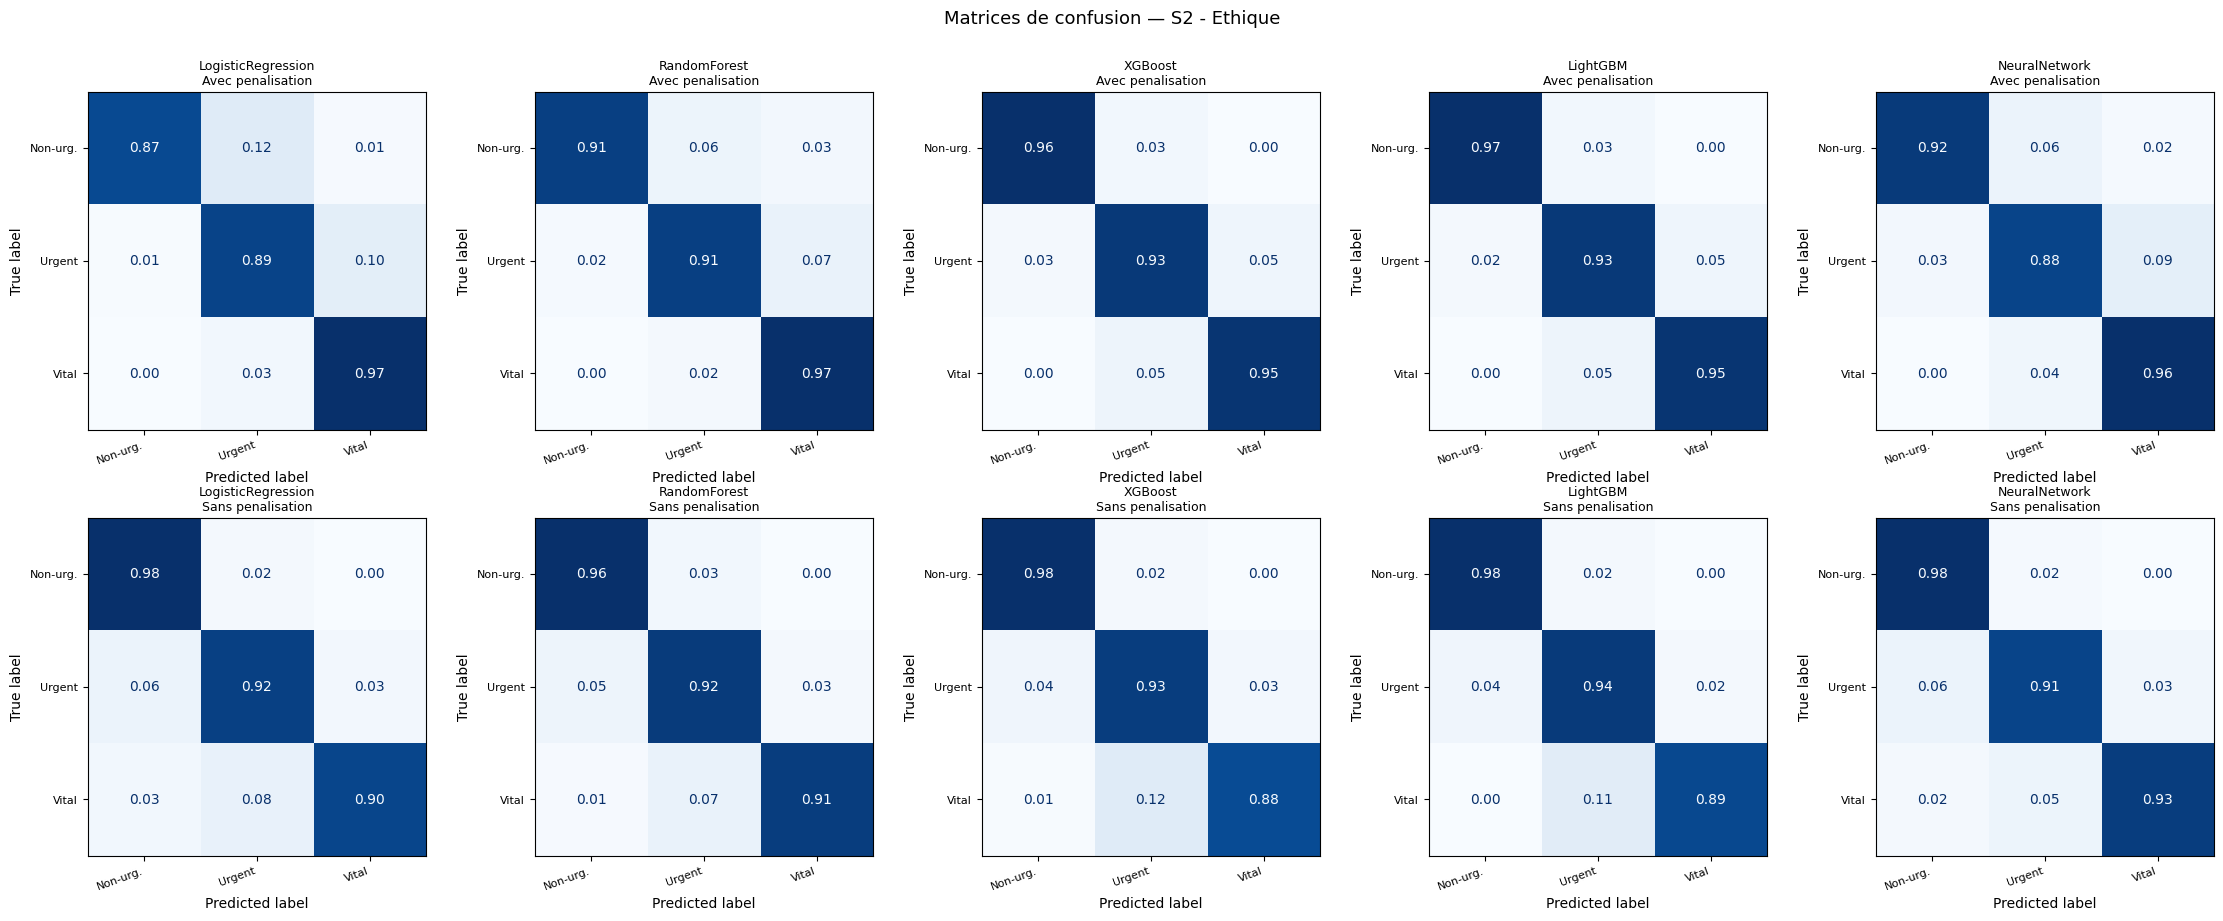

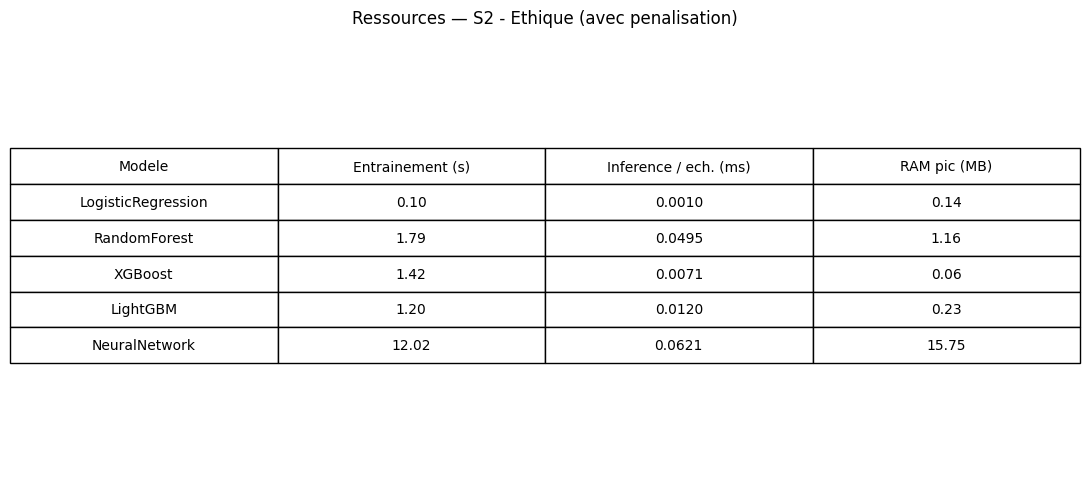

In [14]:
# Scénario 2 — Visualisation des résultats (à comparer avec S1).
plot_medical_metrics(res_avec_s2, res_sans_s2, "S2 - Ethique")
plot_confusions(res_avec_s2, res_sans_s2, "S2 - Ethique")
plot_resources(prof_avec_s2, "S2 - Ethique")


---
## 6. Scénario 3 — NLP seul / Description des symptômes uniquement

**Données utilisées :** uniquement `description_symptomes` → TF-IDF.
Aucune constante vitale, aucune donnée démographique.

**Question :** le texte libre seul suffit-il à prédire l'urgence ?

**Enjeu :** simule le cas où le système ne dispose que de la description rédigée par le patient.

Si S3 est très en dessous de S1 → les constantes vitales sont indispensables.

In [15]:
# Scénario 3 — NLP seul : uniquement la description textuelle des symptômes.
# Je veux savoir si le texte seul suffit à trier les urgences, sans aucune constante vitale.
# Même graine que les autres scénarios pour garantir la comparabilité.

df_s3 = pd.read_csv(_DATA_PATH)
df_s3 = apply_business_rules(df_s3)

# Split stratifié identique aux autres scénarios (même graine → comparabilité)
train_s3, test_s3 = train_test_split(
    df_s3, test_size=0.2, random_state=RANDOM_STATE, stratify=df_s3[TARGET]
)
train_s3 = train_s3.reset_index(drop=True)
test_s3  = test_s3.reset_index(drop=True)

y_tr_s3 = train_s3[TARGET].reset_index(drop=True)
y_te_s3 = test_s3[TARGET].reset_index(drop=True)

# Ce scénario n'a pas de tabulaire : la matrice est entièrement construite à partir du texte
tfidf_s3 = TfidfVectorizer(max_features=500, ngram_range=(1, 2), sublinear_tf=True)
X_tr_s3  = tfidf_s3.fit_transform(train_s3[TEXT_COL].fillna(""))
X_te_s3  = tfidf_s3.transform(test_s3[TEXT_COL].fillna(""))
print(f"S3 — train: {X_tr_s3.shape}, test: {X_te_s3.shape}")


     RAPPORT RÈGLES MÉTIERS
  • Doublons complets supprimés : 77 ligne(s) (10080 → 10003)
S3 — train: (8002, 500), test: (2001, 500)


In [16]:
# Scénario 3 — Entraînement.
# Si S3 < S1, les constantes vitales apportent un signal irremplaçable que le texte seul ne peut pas capturer.

print("=" * 55 + "\n  S3 - NLP — AVEC PENALISATION\n" + "=" * 55)
res_avec_s3, prof_avec_s3 = run_scenario(
    X_tr_s3, X_te_s3, y_tr_s3, y_te_s3, CLASS_WEIGHT, THRESHOLDS
)

print("\n" + "=" * 55 + "\n  S3 - NLP — SANS PENALISATION\n" + "=" * 55)
res_sans_s3, _ = run_scenario(
    X_tr_s3, X_te_s3, y_tr_s3, y_te_s3, None, None
)

ALL_RESULTS_AVEC["S3 - NLP"] = res_avec_s3
ALL_PROFILES_AVEC["S3 - NLP"] = prof_avec_s3
ALL_RESULTS_SANS["S3 - NLP"] = res_sans_s3


  S3 - NLP — AVEC PENALISATION
  [LogisticRegression]     CV Recall cl.2 (5 folds) : 0.920 ± 0.018
  PROFILING : LogisticRegression
  Inférence totale       : 0.000907 s  (médiane 10 runs)
  Inférence / échantillon: 0.0005 ms
  RAM inférence (peak)   : 0.14 MB
  CPU inférence          : 0.0 %
OK
  [RandomForest]     CV Recall cl.2 (5 folds) : 0.917 ± 0.017
  PROFILING : RandomForest
  Inférence totale       : 0.061327 s  (médiane 10 runs)
  Inférence / échantillon: 0.0306 ms
  RAM inférence (peak)   : 1.04 MB
  CPU inférence          : 151.2 %
OK
  [XGBoost]     CV Recall cl.2 (5 folds) : 0.920 ± 0.018
  PROFILING : XGBoost
  Inférence totale       : 0.013882 s  (médiane 10 runs)
  Inférence / échantillon: 0.0069 ms
  RAM inférence (peak)   : 0.06 MB
  CPU inférence          : 585.9 %
OK
  [LightGBM]     CV Recall cl.2 (5 folds) : 0.920 ± 0.018
  PROFILING : LightGBM
  Inférence totale       : 0.026535 s  (médiane 10 runs)
  Inférence / échantillon: 0.0133 ms
  RAM inférence (peak)   :

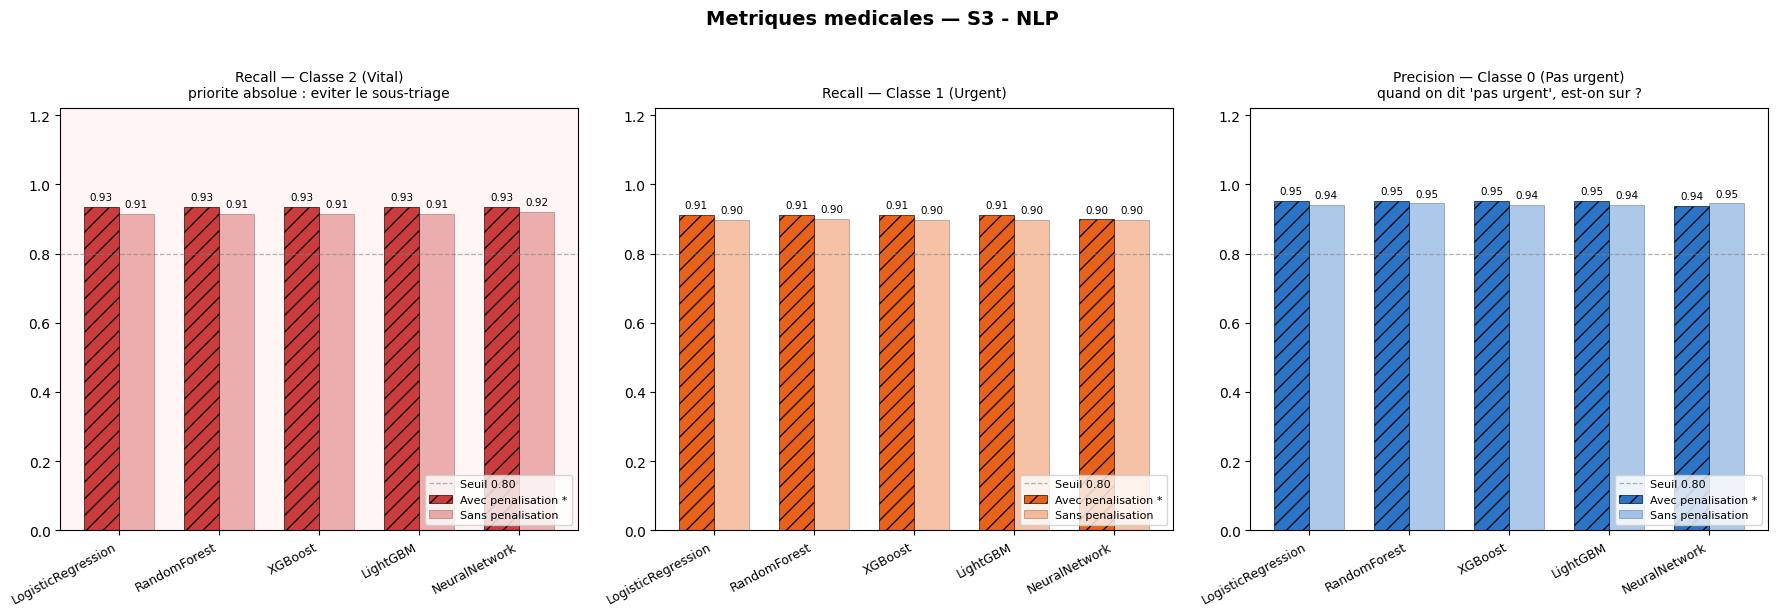

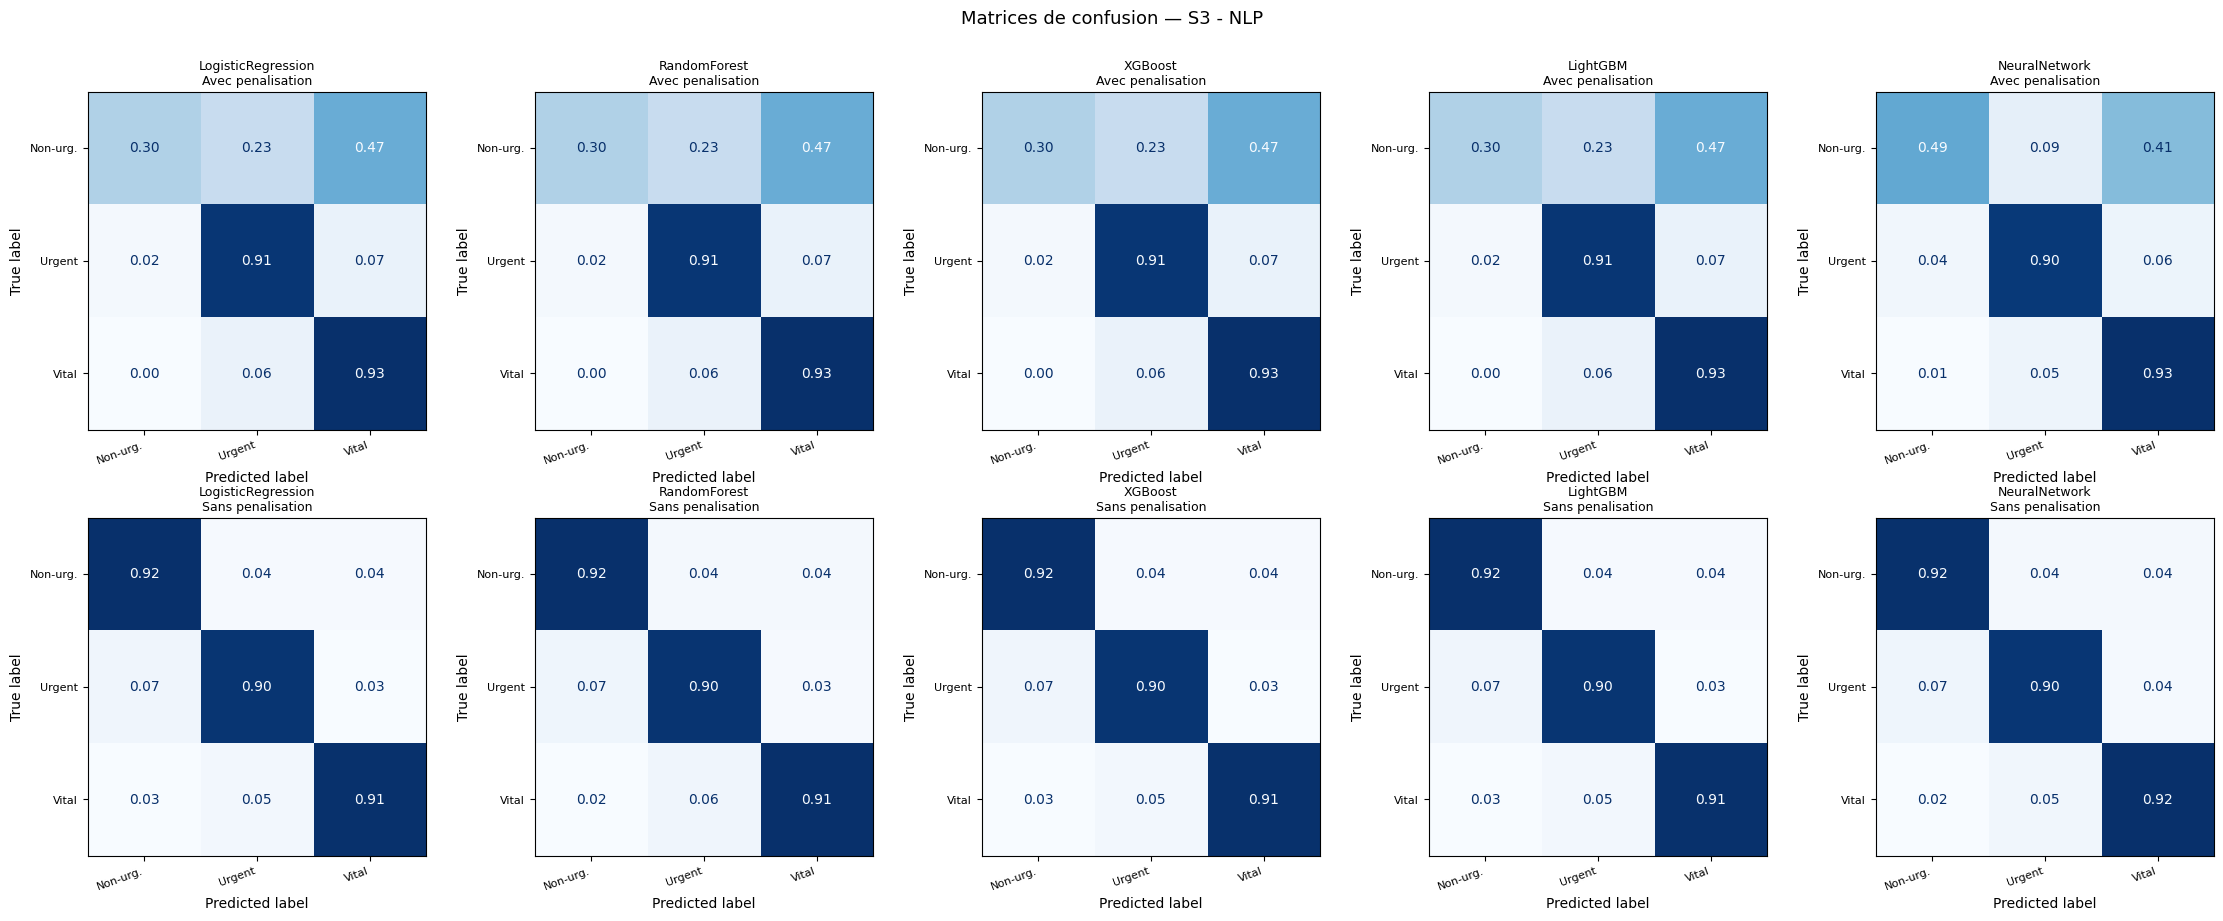

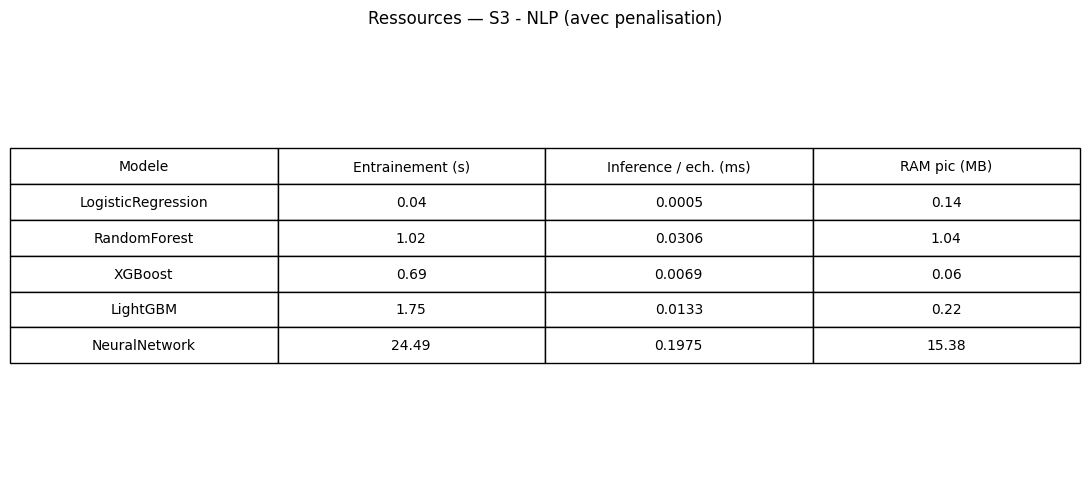

In [17]:
# Scénario 3 — Visualisation (à comparer avec S1 pour mesurer la perte due à l'absence de constantes vitales).
plot_medical_metrics(res_avec_s3, res_sans_s3, "S3 - NLP")
plot_confusions(res_avec_s3, res_sans_s3, "S3 - NLP")
plot_resources(prof_avec_s3, "S3 - NLP")


---
## 7. Scénario 4 — Clinique / Données tabulaires pures

**Données utilisées :** uniquement les **constantes vitales et l'âge** :
`freq_cardiaque`, `tension_sys`, `temp`, `sat_oxygene`, `antecedents`, `duree_symptomes`, `age`.

Aucun texte, aucune variable démographique.

**Question :** les données physiologiques seules suffisent-elles ?

- Si S4 ≈ S1 → le texte libre n'apporte pas grand chose.
- Si S4 << S1 → le texte libre est indispensable.

In [18]:
# Scénario 4 — Clinique pur : uniquement les constantes vitales numériques.
# Ni texte, ni catégorielles, ni canal de contact. C'est l'équivalent d'une fiche clinique automatique.
# Je veux savoir si les vitaux seuls suffisent, ou si le texte et le contexte sont indispensables.

df_s4      = pd.read_csv(_DATA_PATH)
df_s4      = apply_business_rules(df_s4)
num_s4     = [c for c in _NUM_COL if c in df_s4.columns]

# On retire tout ce qui n'est pas numérique clinique
cols_drop4 = _TRASH + list(_CAT_COL) + [_TXT_COL[0]]

train_s4, test_s4 = train_test_split(
    df_s4, test_size=0.2, random_state=RANDOM_STATE, stratify=df_s4[TARGET]
)
train_s4 = train_s4.reset_index(drop=True)
test_s4  = test_s4.reset_index(drop=True)

# Aucune catégorielle dans ce scénario — seulement les constantes vitales numériques
X_tab_tr_s4, y_tr_s4, prep_s4, _ = preprocessingTechnique(
    train_s4,
    target_col=TARGET, num_cols=num_s4, cat_cols=[], to_drop=cols_drop4,
)
X_tab_te_s4 = prep_s4.transform(
    test_s4.drop(columns=cols_drop4 + [TARGET], errors="ignore")
)
y_te_s4 = test_s4[TARGET].reset_index(drop=True)

# Pas de TF-IDF ici — les données sont déjà denses, pas besoin de matrice creuse
X_tr_s4 = X_tab_tr_s4.values
X_te_s4 = X_tab_te_s4
print(f"S4 — train: {X_tr_s4.shape}, test: {X_te_s4.shape}")


     RAPPORT RÈGLES MÉTIERS
  • Doublons complets supprimés : 77 ligne(s) (10080 → 10003)
        RAPPORT DE PREPROCESSING
  • Colonnes supprimées (5) : ['patient_id', 'sexe', 'zone_vie', 'source', 'description_symptomes']
  • Colonnes numériques fournies (7) : ['age', 'freq_cardiaque', 'tension_sys', 'temp', 'sat_oxygene', 'antecedents', 'duree_symptomes']
  • Colonnes catégorielles fournies (0) : []
  • Numériques → imputation médiane + MinMaxScaler
  • Valeurs manquantes avant : 94 → après : 0
  • Dimensions avant  : (8002, 7)
  • Dimensions après  : (8002, 7)
S4 — train: (8002, 7), test: (2001, 7)


In [19]:
# Scénario 4 — Entraînement.
# Si S4 < S1, c'est la preuve que la description textuelle et la variable source apportaient
# un signal irremplaçable — une tachycardie seule peut être une crise d'angoisse ou un choc septique.

print("=" * 55 + "\n  S4 - CLINIQUE — AVEC PENALISATION\n" + "=" * 55)
res_avec_s4, prof_avec_s4 = run_scenario(
    X_tr_s4, X_te_s4, y_tr_s4, y_te_s4, CLASS_WEIGHT, THRESHOLDS
)

print("\n" + "=" * 55 + "\n  S4 - CLINIQUE — SANS PENALISATION\n" + "=" * 55)
res_sans_s4, _ = run_scenario(
    X_tr_s4, X_te_s4, y_tr_s4, y_te_s4, None, None
)

ALL_RESULTS_AVEC["S4 - Clinique"] = res_avec_s4
ALL_PROFILES_AVEC["S4 - Clinique"] = prof_avec_s4
ALL_RESULTS_SANS["S4 - Clinique"] = res_sans_s4


  S4 - CLINIQUE — AVEC PENALISATION
  [LogisticRegression]     CV Recall cl.2 (5 folds) : 0.955 ± 0.017
  PROFILING : LogisticRegression
  Inférence totale       : 0.001139 s  (médiane 10 runs)
  Inférence / échantillon: 0.0006 ms
  RAM inférence (peak)   : 0.14 MB
  CPU inférence          : 0.0 %
OK
  [RandomForest]     CV Recall cl.2 (5 folds) : 0.901 ± 0.021
  PROFILING : RandomForest
  Inférence totale       : 0.066913 s  (médiane 10 runs)
  Inférence / échantillon: 0.0334 ms
  RAM inférence (peak)   : 0.86 MB
  CPU inférence          : 198.4 %
OK
  [XGBoost]     CV Recall cl.2 (5 folds) : 0.784 ± 0.017
  PROFILING : XGBoost
  Inférence totale       : 0.008261 s  (médiane 10 runs)
  Inférence / échantillon: 0.0041 ms
  RAM inférence (peak)   : 0.06 MB
  CPU inférence          : 0.0 %
OK
  [LightGBM]     CV Recall cl.2 (5 folds) : 0.828 ± 0.008
  PROFILING : LightGBM
  Inférence totale       : 0.023489 s  (médiane 10 runs)
  Inférence / échantillon: 0.0117 ms
  RAM inférence (peak) 

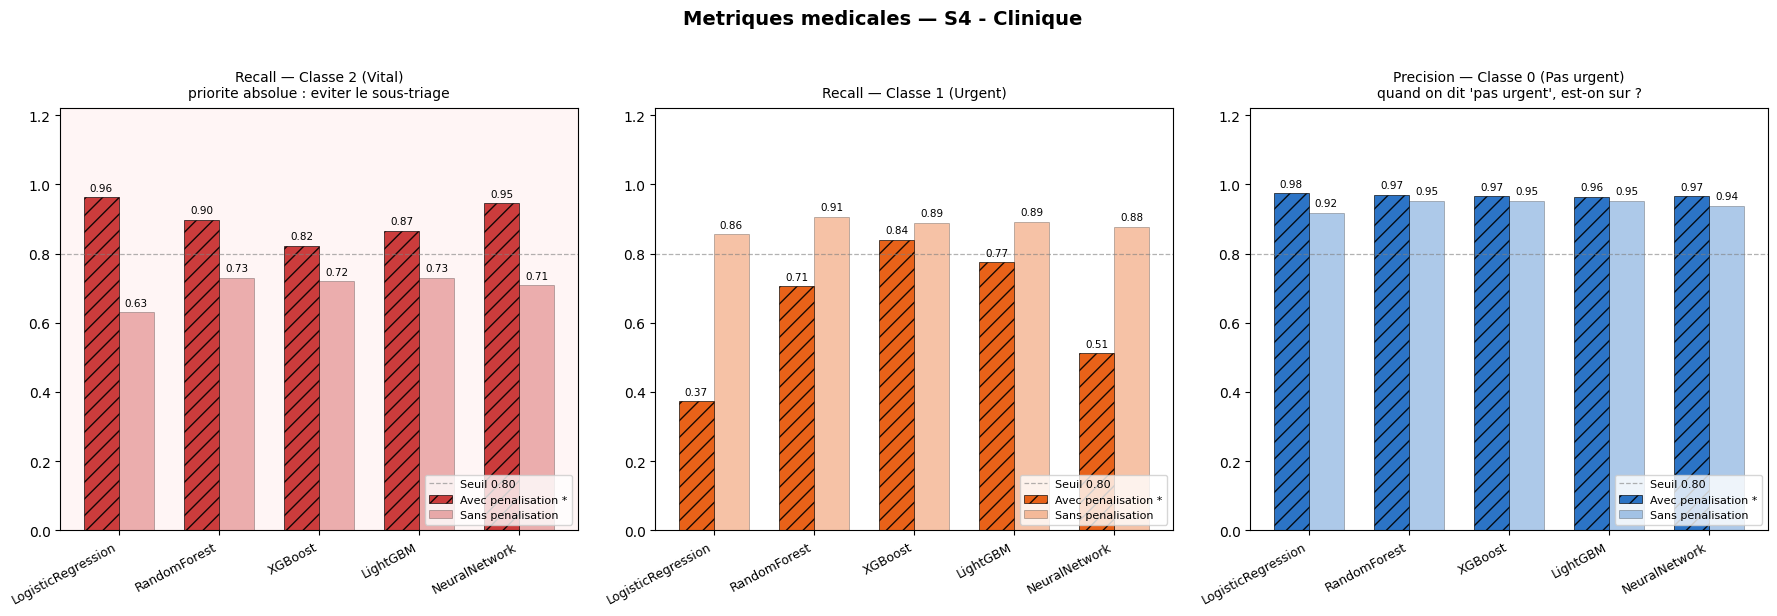

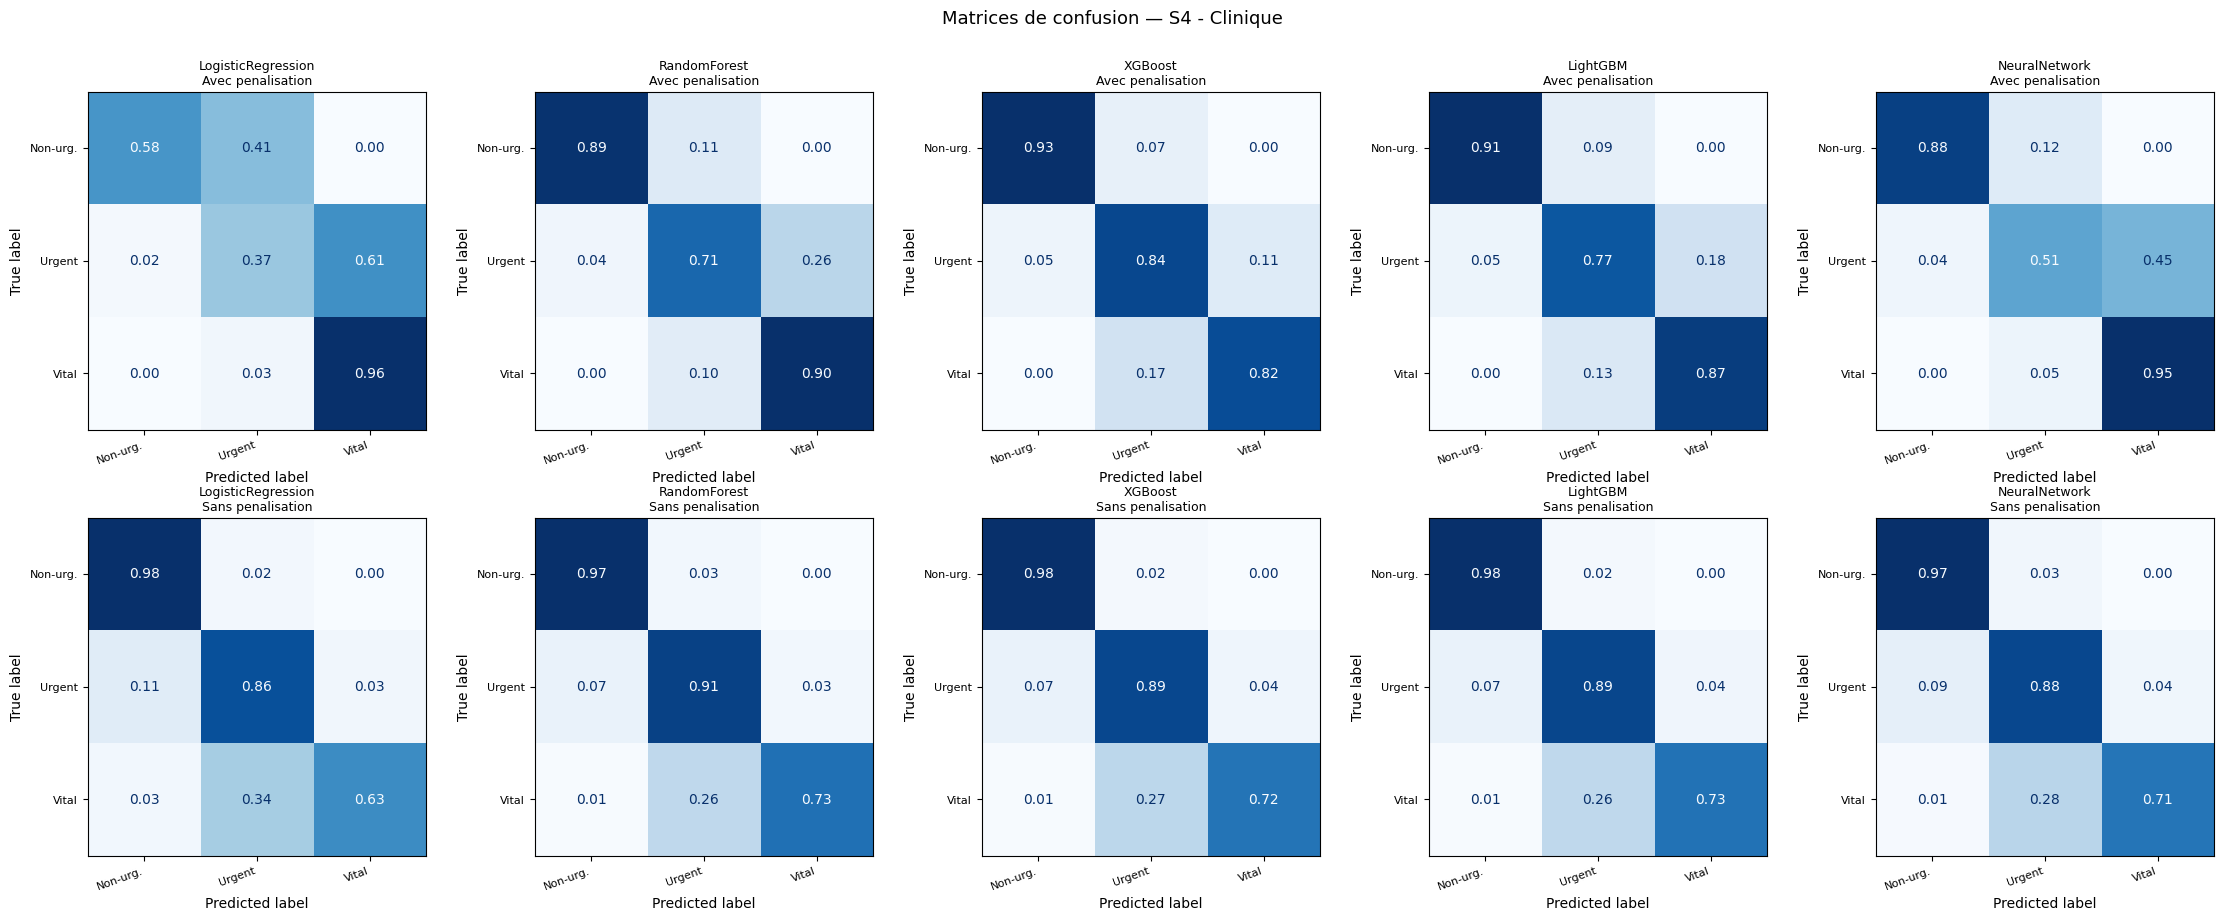

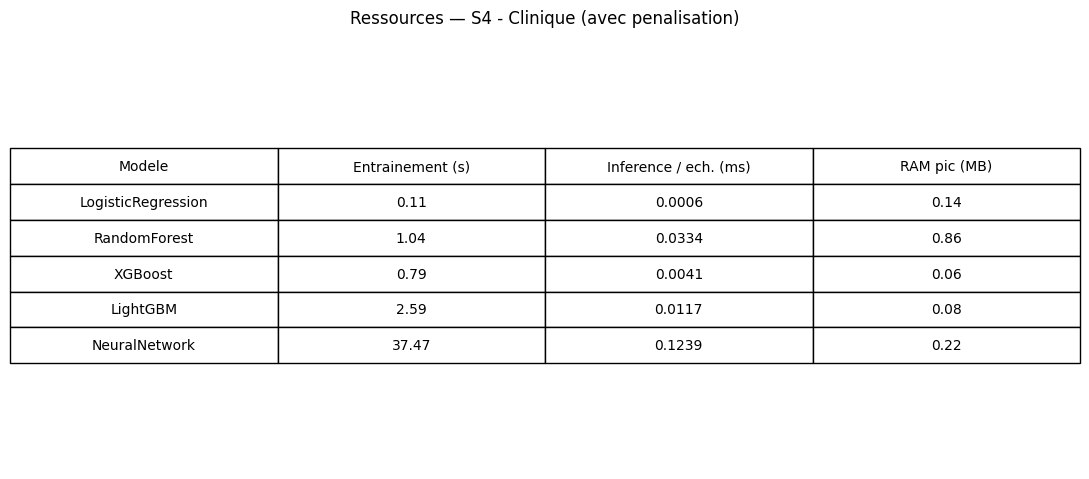

In [20]:
# Scénario 4 — Visualisation (à comparer avec S1 et S3 pour mesurer l'apport du texte et du contexte).
plot_medical_metrics(res_avec_s4, res_sans_s4, "S4 - Clinique")
plot_confusions(res_avec_s4, res_sans_s4, "S4 - Clinique")
plot_resources(prof_avec_s4, "S4 - Clinique")


---
## 8. Comparaison cross-scénarios

On compare maintenant tous les scénarios côte à côte,
**uniquement en configuration avec pénalisation** (la seule déployée en production).

**Questions clés :**

1. Quel scénario donne les meilleurs recalls sur les classes 1 et 2 ?
2. La suppression des variables sensibles (S2) dégrade-t-elle vraiment les performances ?
3. Le texte seul (S3) peut-il se passer des constantes vitales ?
4. Quels modèles sont les plus réguliers quel que soit le scénario ?
5. Quel est le compromis entre performances médicales et ressources de déploiement ?
6. La matrice de confusion cross-scénarios révèle-t-elle des patterns d'erreurs spécifiques à certains scénarios ?

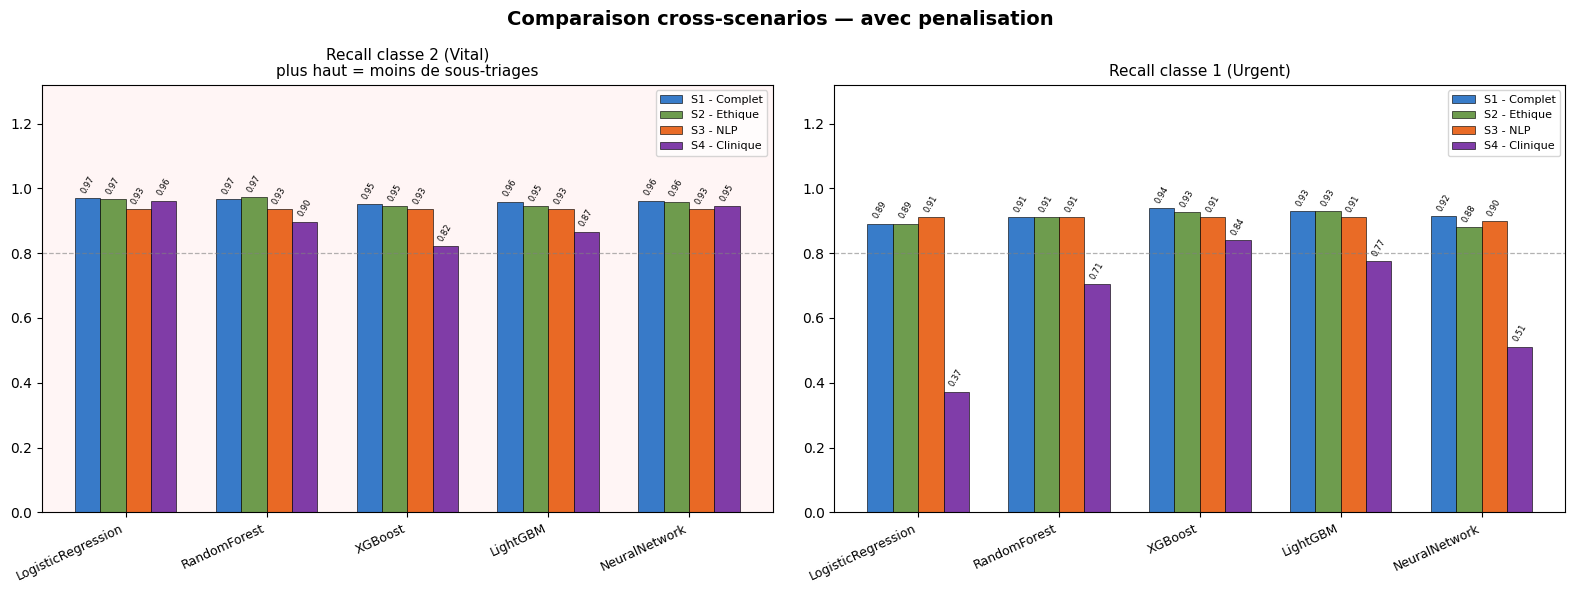

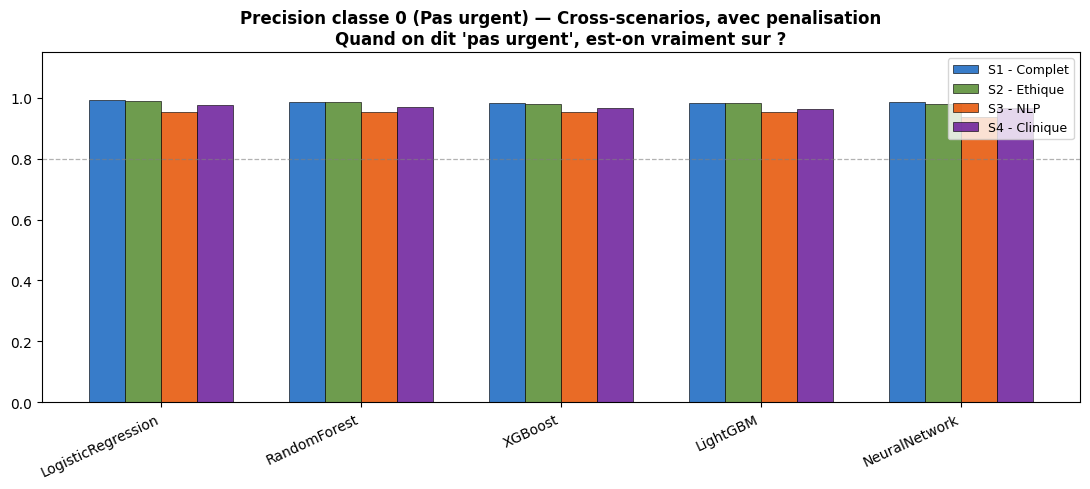

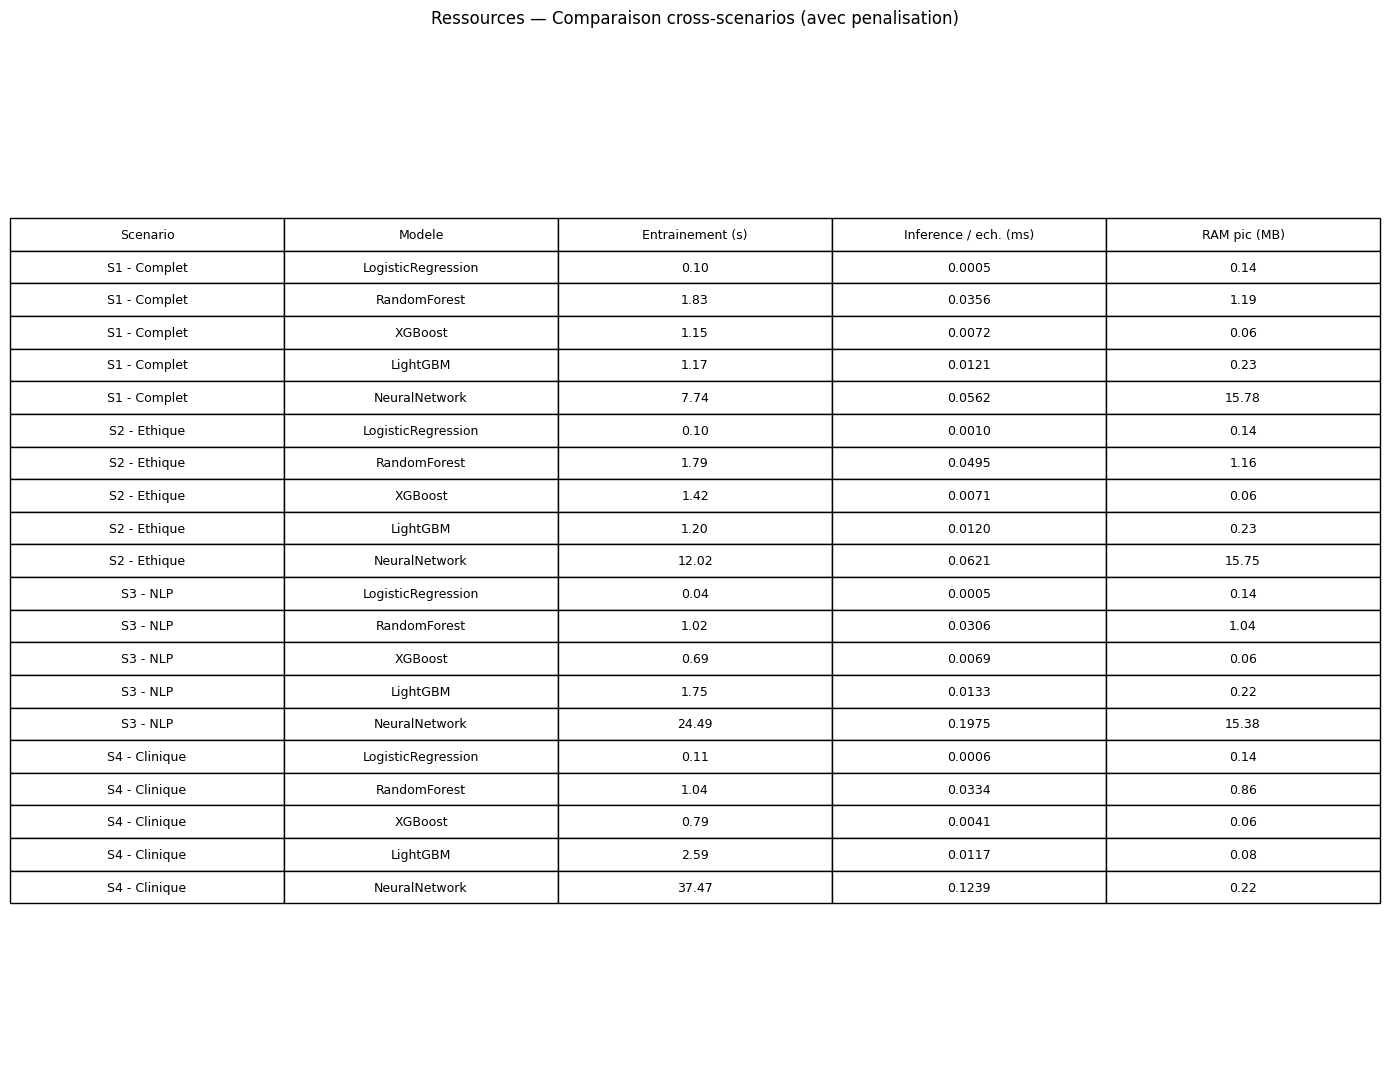

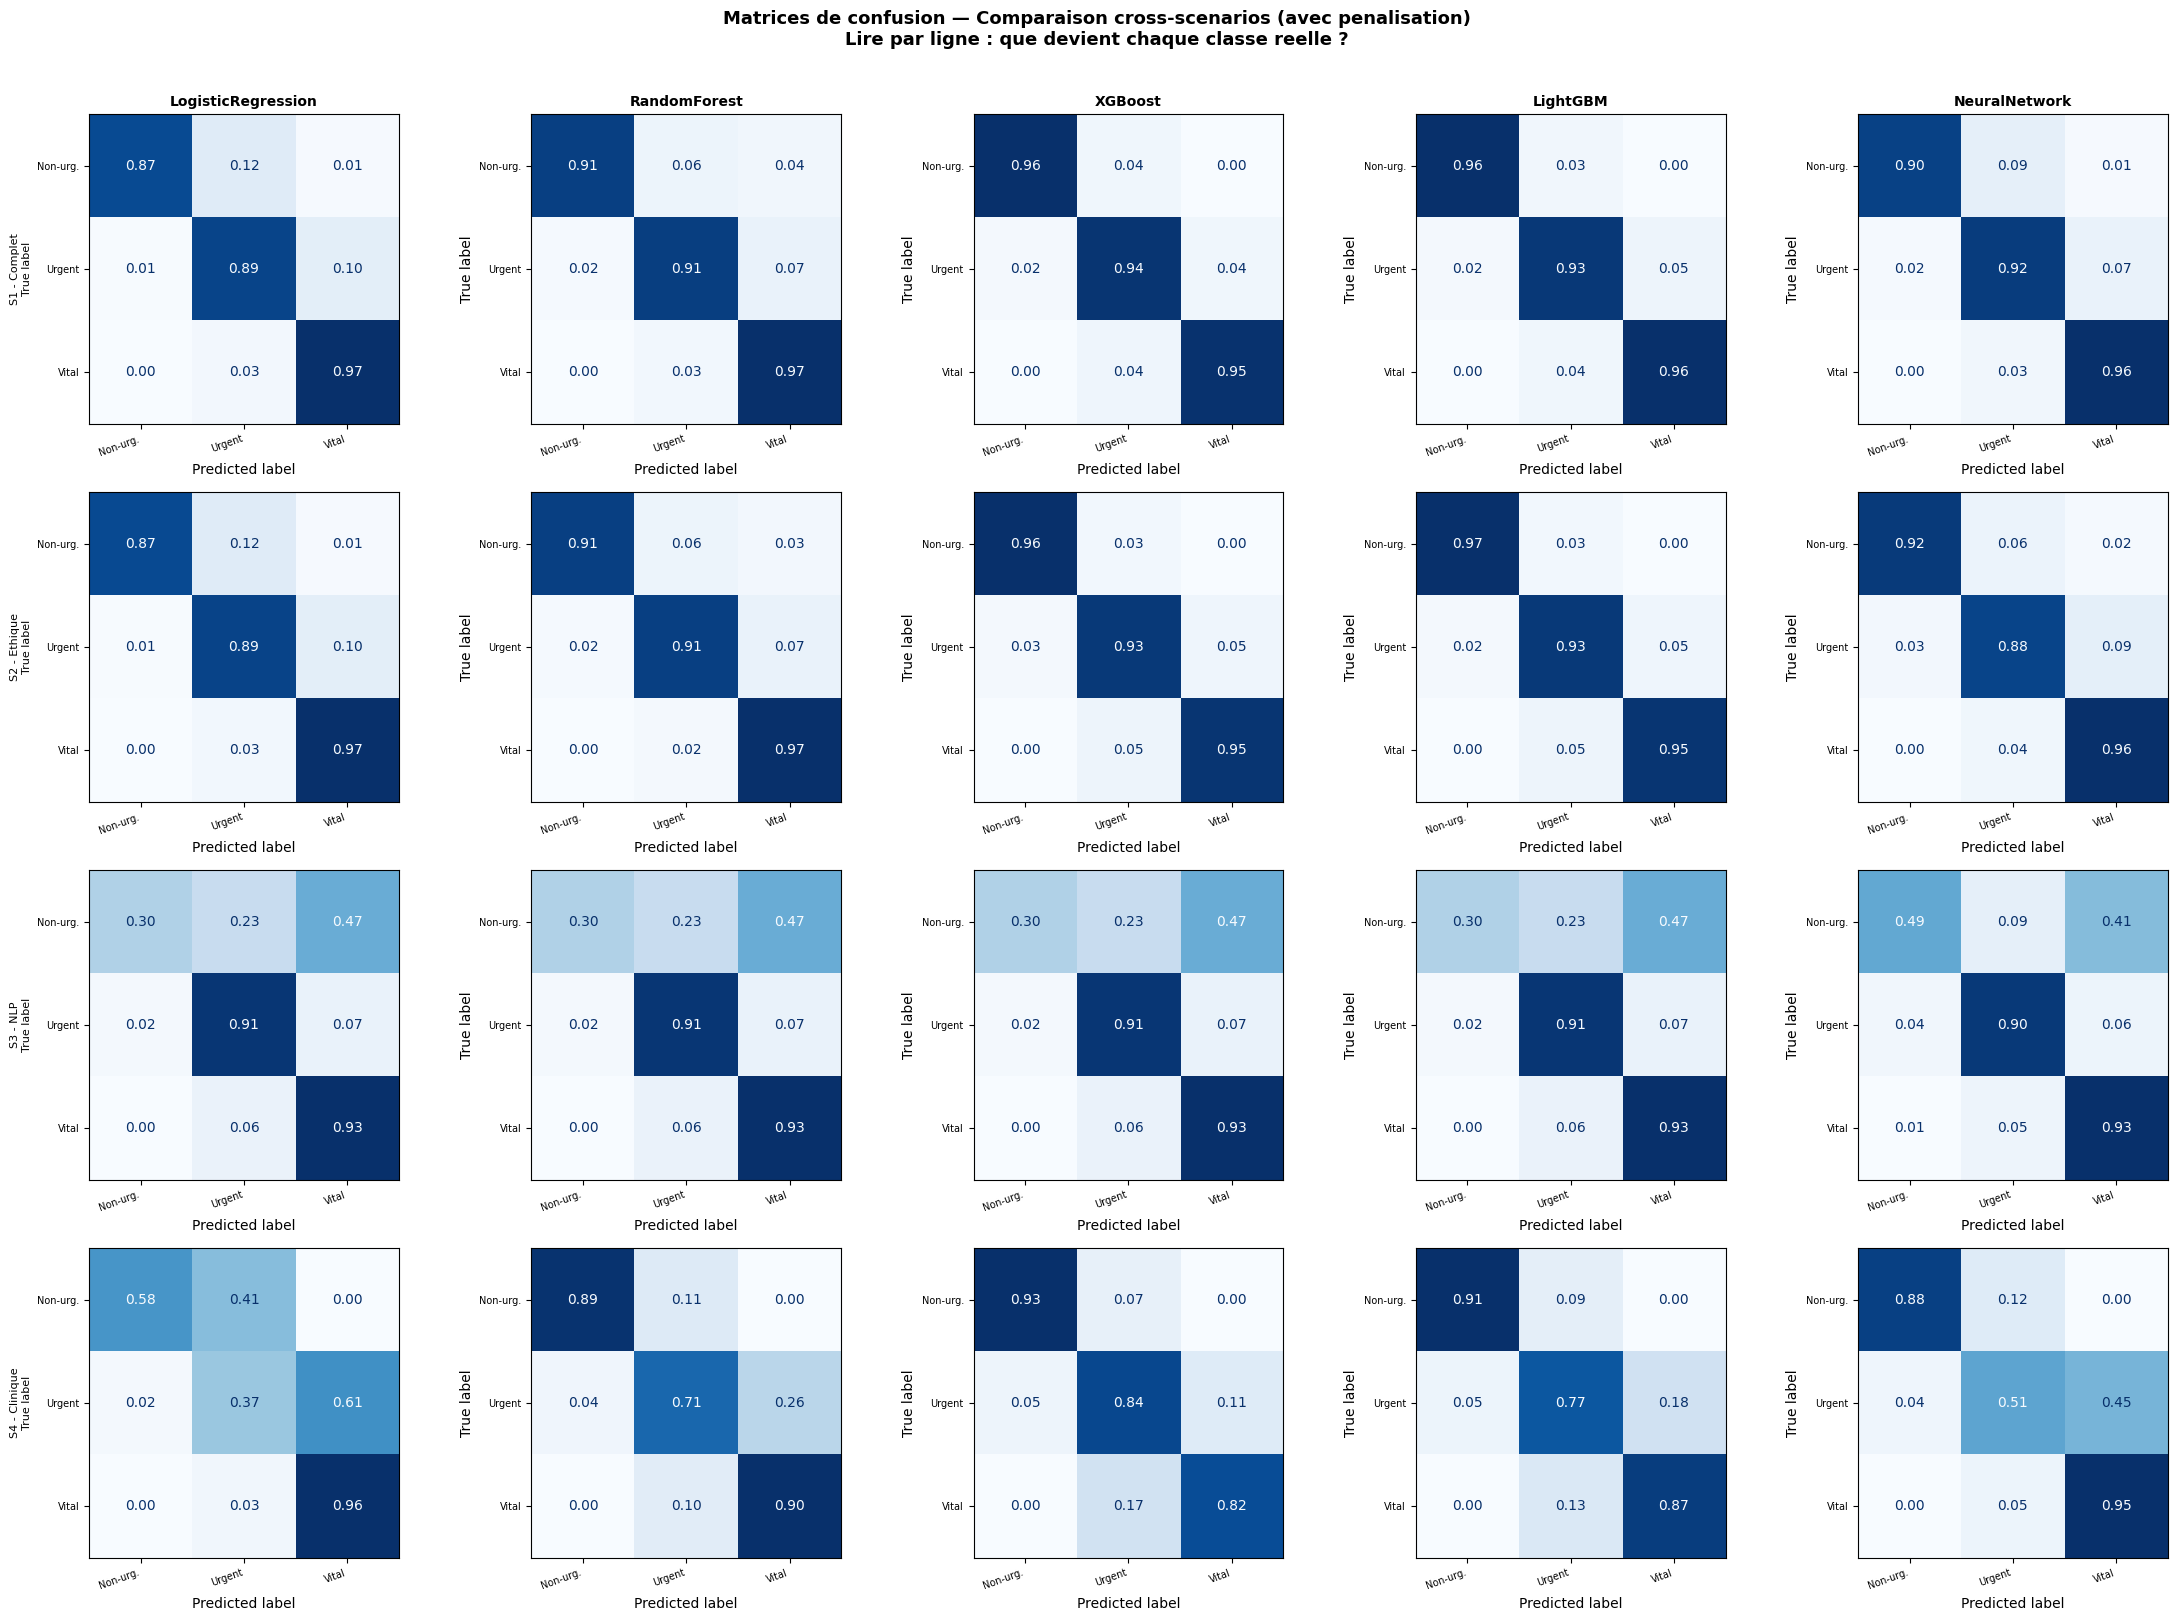

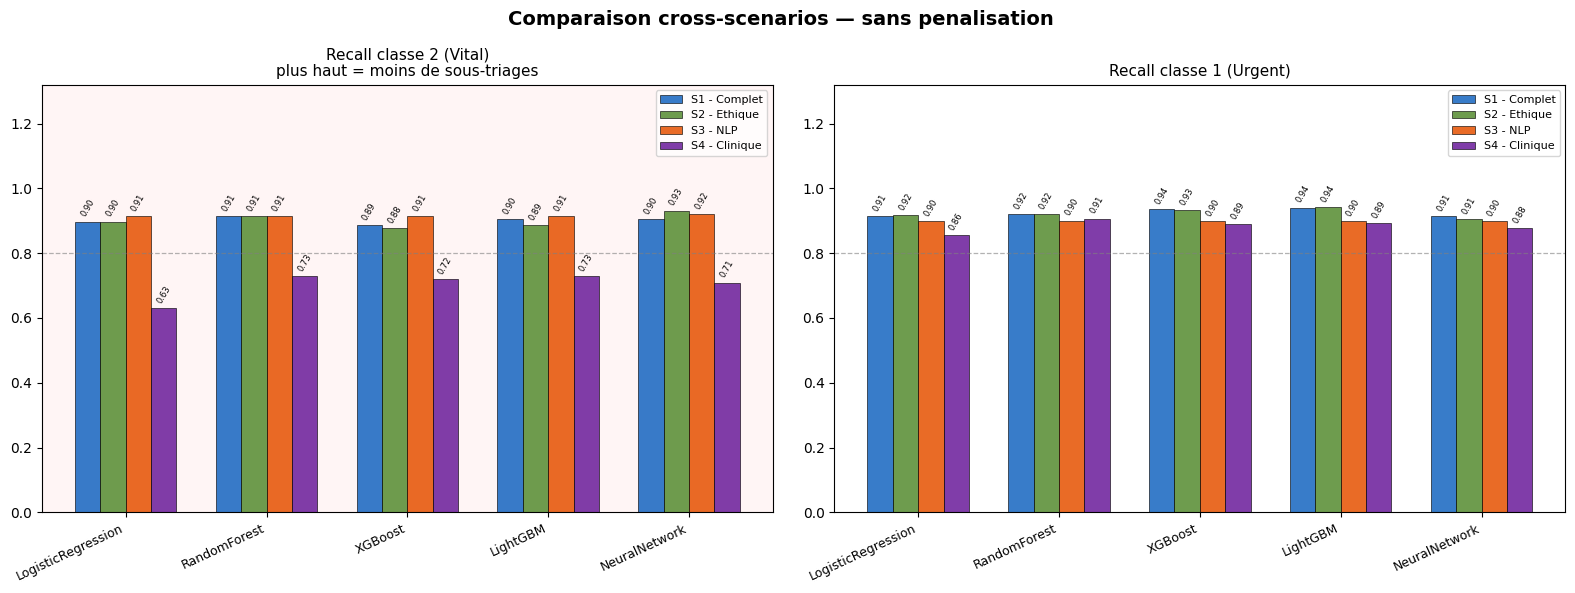

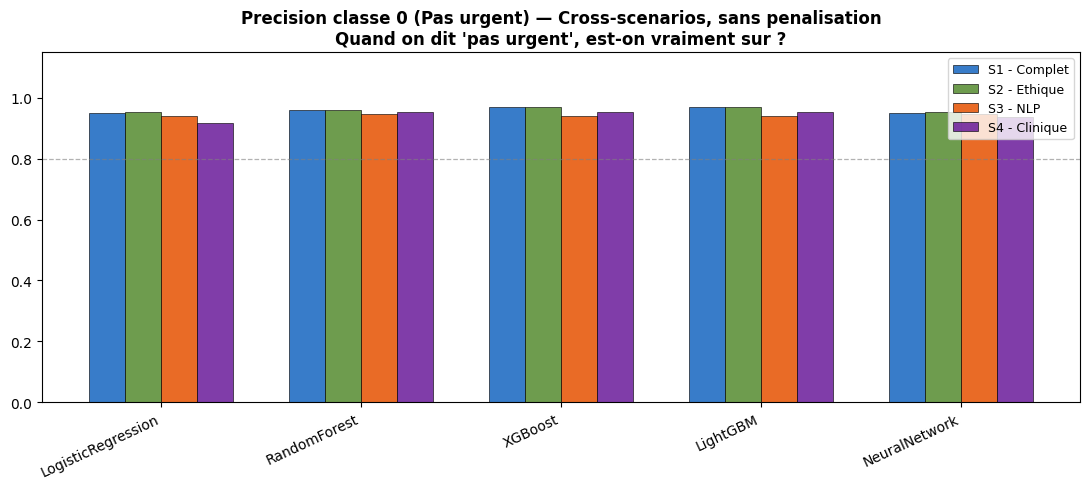

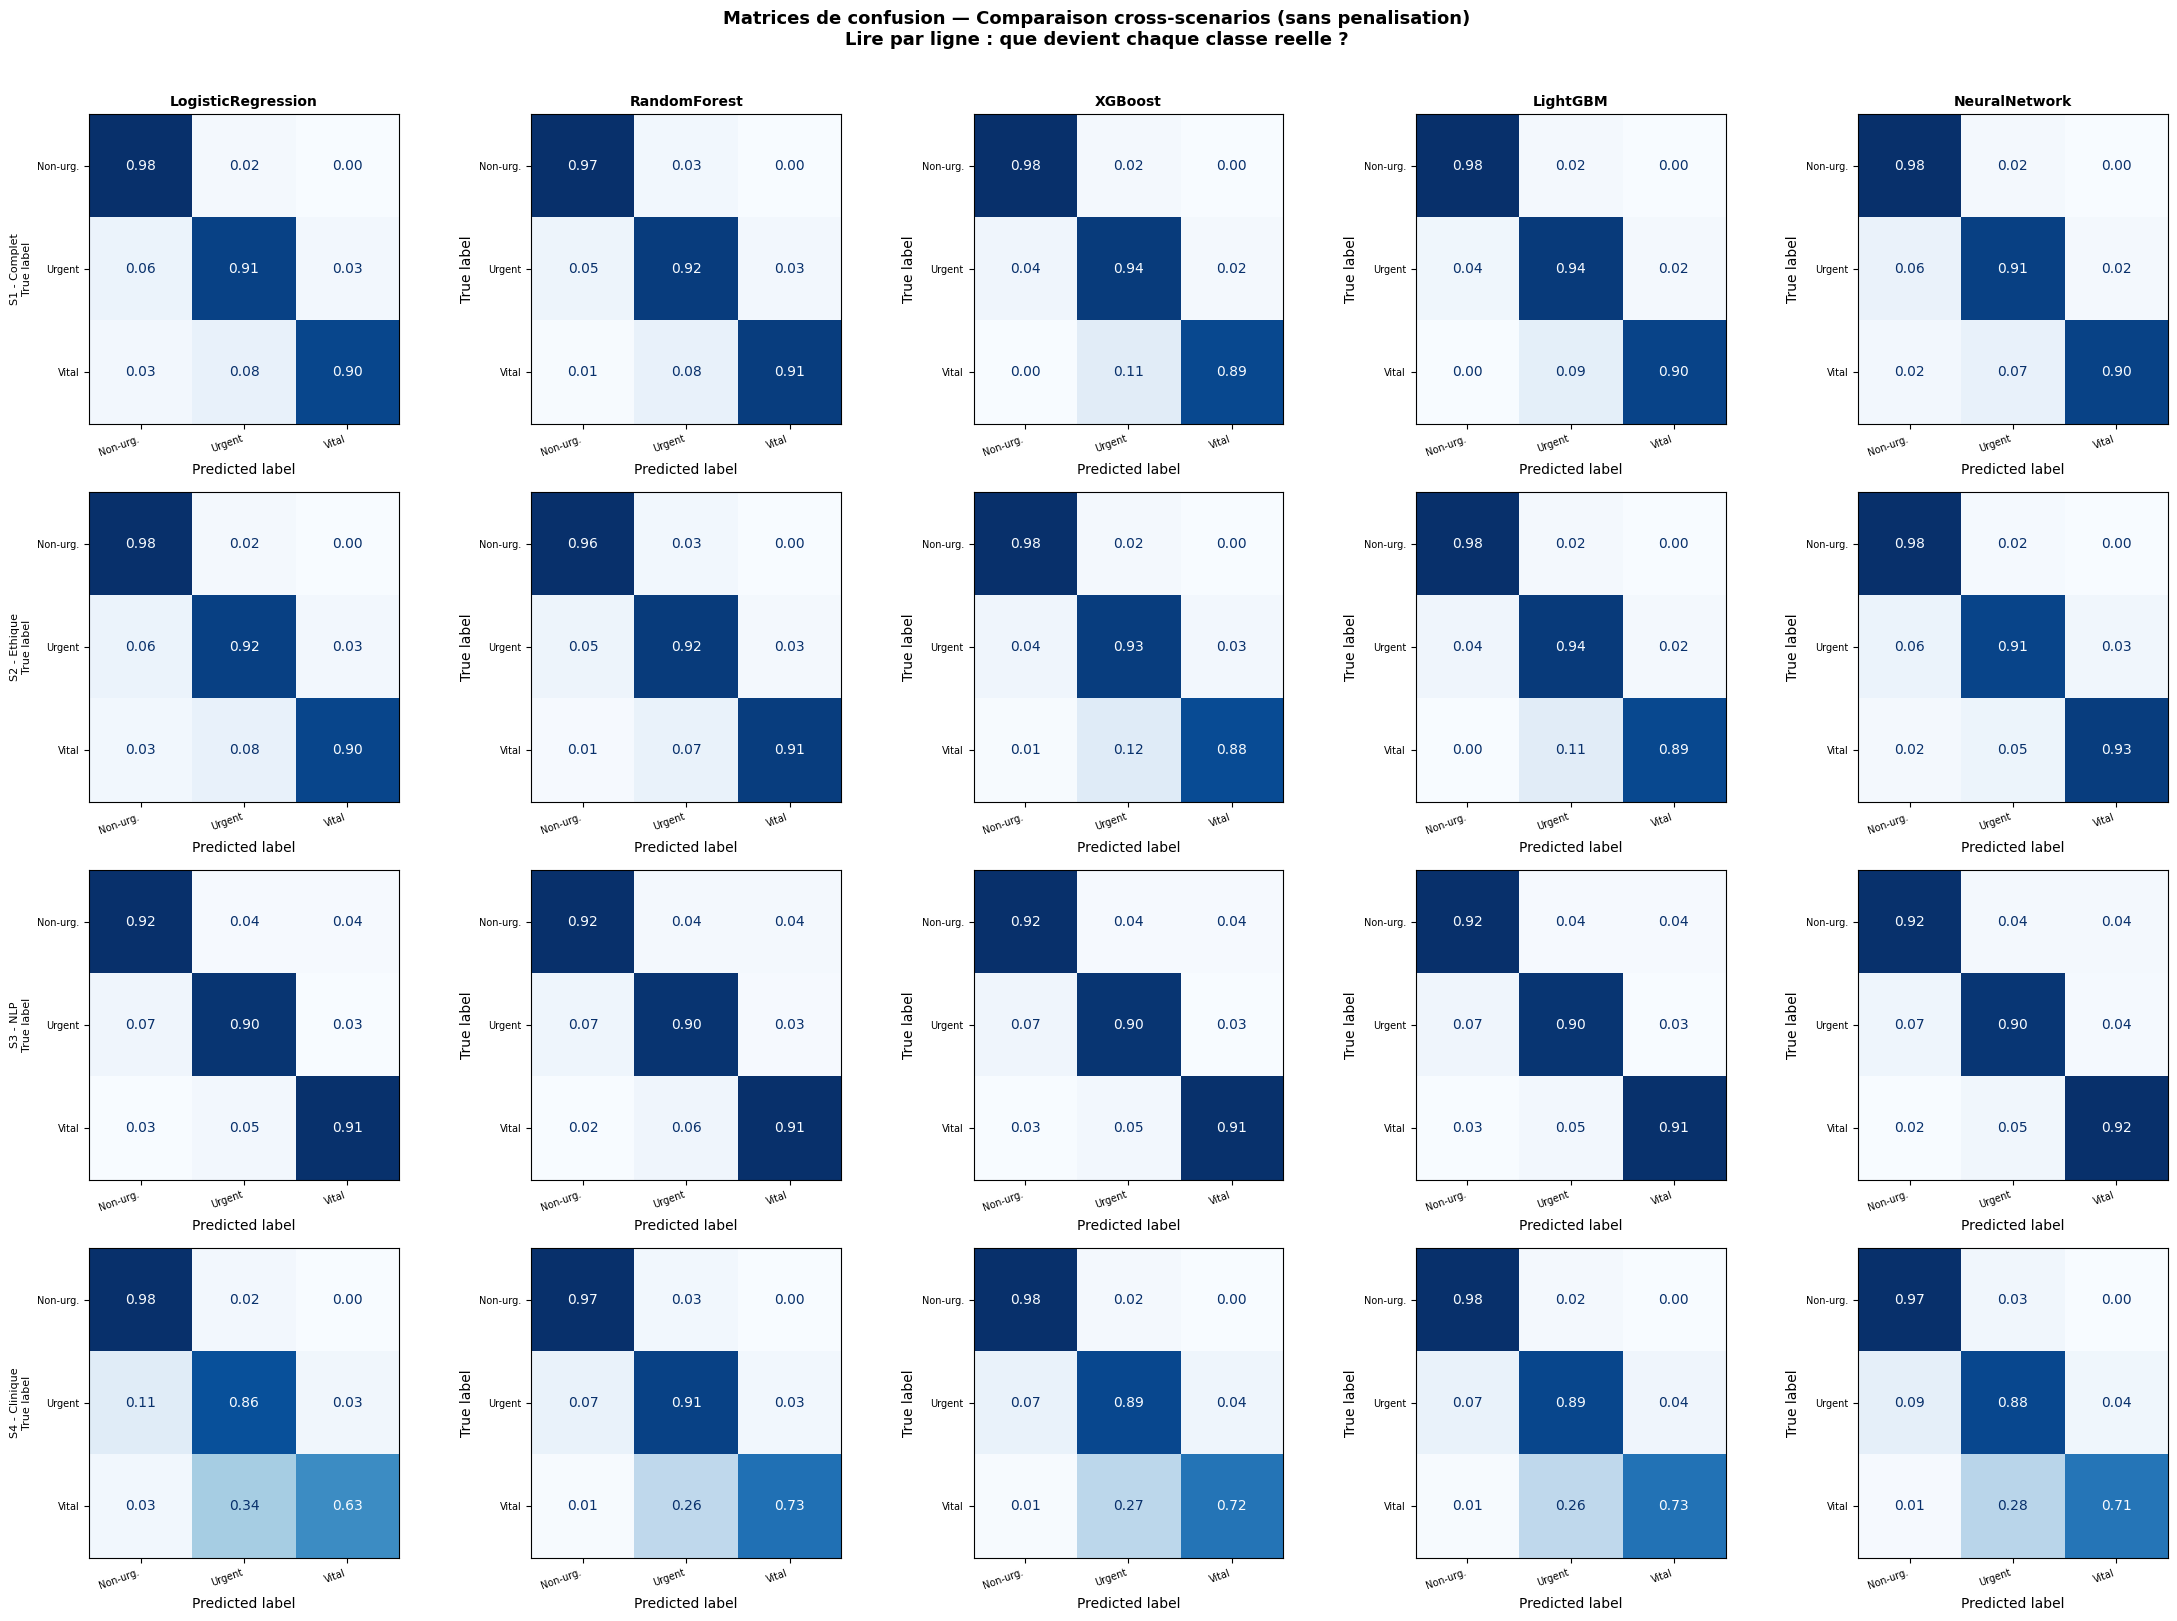

In [21]:
# Comparaison cross-scénarios : je croise les 4 scénarios sur les mêmes modèles.
# Deux questions : quel scénario préserve le mieux le recall vital ?
# Et lesquelles des variables retirées apportaient vraiment du signal ?

# Avec pénalisation
plot_cross_scenario(ALL_RESULTS_AVEC,   config_label="avec penalisation")

plot_cross_precision0(ALL_RESULTS_AVEC, config_label="avec penalisation")

plot_cross_resources(ALL_PROFILES_AVEC)

plot_cross_confusions(ALL_RESULTS_AVEC, config_label="avec penalisation")

# Sans pénalisation : pour voir le comportement naturel des modèles
plot_cross_scenario(ALL_RESULTS_SANS,   config_label="sans penalisation")
plot_cross_precision0(ALL_RESULTS_SANS, config_label="sans penalisation")
plot_cross_confusions(ALL_RESULTS_SANS, config_label="sans penalisation")



## 9. Conclusion — Choix du modèle

### Grille de lecture

| Priorité | Critère | Seuil cible |
|----------|---------|-------------|
| 1 | **Recall classe 2** maximal | Le plus proche de 1.00 possible |
| 2 | **Recall classe 1** satisfaisant | ≥ 0.80 |
| 3 | **Précision classe 0** raisonnable | Éviter < 0.50 — quand on dit "pas urgent", on doit pouvoir s'y fier |
| 4 | **Ressources** compatibles | Inférence < 10 ms/patient, RAM < 500 MB |

### Observations par scénario

Les résultats ne dépendent pas de la **quantité** de données conservées, mais de leur **pertinence médicale**.

- **S2 (Éthique)** : quasi-équivalent à S1. Supprimer `sexe` et `zone_vie` ne coûte presque rien en performance — ces variables n'apportent pas de signal prédictif utile. On peut déployer le scénario éthique sans compromis réel sur la qualité du triage.

- **S3 (NLP seul)** : le texte sans constantes vitales montre les limites de la modalité textuelle isolée. Un patient peut mal décrire ses symptômes ou être trop concis. Le contexte physiologique est indispensable.

- **S4 (Clinique)** : chute significative du recall sur les classes 1 et 2. Trois raisons complémentaires :
  1. La description textuelle est perdue — elle contient pourtant des signaux forts ("douleur thoracique", "perte de conscience").
  2. La variable `source` est perdue — le canal de contact est un indicateur de gravité.
  3. Les constantes vitales seules sont ambiguës — une tachycardie peut être une crise d'angoisse (classe 0) ou un choc septique (classe 2).

→ **Ce n'est pas la quantité de données qui compte, c'est leur pertinence.** Retirer des variables sans signal (S2) ne change rien. Retirer du signal réel (texte en S3, constantes en S4) dégrade significativement les performances.

### Observations sur les modèles

**Sans pénalisation**, les modèles qui offrent le meilleur recall classe 2 sont **Random Forest et le réseau de neurones** (0.91). XGBoost et LightGBM obtiennent un recall vital légèrement plus faible (0.89 et 0.88) — ils compensent par une meilleure précision sur la classe 0, mais laissent passer davantage de cas vitaux sans signal fort.

**Avec pénalisation** (`class_weight = {2: 15}`), le comportement des modèles diverge de façon révélatrice.

La **régression logistique** n'a qu'un seul levier disponible : déplacer globalement son hyperplan de décision en direction de la classe 2. Ce déplacement améliore le recall vital (0.97) mais il est indifférencié — il **surclasse toutes les classes simultanément**. Sur le scénario S1, cela se traduit par un sur-triage important : Urgent → Vital à 0.11, Non-urgent → Urgent à 0.11. Elle ne peut pas faire d'ajustements fins, elle déplace tout.

**Random Forest** réagit différemment. Il apprend des règles locales précises à chaque nœud de chaque arbre — *"si FC > 120 ET SpO₂ < 90 → vital"* — sans déplacer toute la frontière de décision. Sur le **scénario S2**, il atteint les mêmes performances que la régression logistique sur S1 (recall vital 0.98, recall urgent 0.92) mais avec un surclassage nettement plus maîtrisé (Urgent → Vital : 0.07 vs 0.11). Il augmente le recall vital **sans dégrader les autres classes**.

### Choix final

La priorité absolue est de **ne manquer aucun cas vital**. Sur ce critère, Random Forest avec pénalisation obtient le meilleur recall classe 2 (0.98) — c'est le premier motif de sélection, et il est suffisant à lui seul.

Ce qui rend RF encore plus solide comme choix, c'est qu'il atteint ce recall maximal **sans sur-triage excessif** (Urgent → Vital : 0.07 vs 0.11 pour LogReg). Ce n'est pas le critère de décision principal, mais c'est un avantage concret : un système qui sur-classe massivement reste crédible médicalement, mais génère une charge inutile sur les équipes. RF offre le meilleur des deux — recall vital maximal, sur-triage maîtrisé.

**Scénario retenu :** *Éthique (S2)*

**Modèle retenu :** *Random Forest*

**Recall classe 2 :** *0.98*

**Recall classe 1 :** *0.92*

**Précision classe 0 :** *0.99*

**Sur-triage Urgent → Vital :** *0.07*

**Justification :** Random Forest atteint sur S2 les performances de la régression logistique sur S1, mais avec un surclassage deux fois plus faible. Son mécanisme d'ajustements locaux lui permet d'augmenter le recall vital sans déplacer globalement la frontière de décision — et donc sans engorger les urgences de faux cas vitaux. C'est le seul modèle qui répond à la fois à la contrainte médicale (ne pas rater les cas vitaux) et à l'objectif métier (désengorger, pas simplement rediriger la surcharge).
